# Australia Climate Forecasting + Extremes (Group Project) — End-to-End Notebook

This notebook is designed to be an **end-to-end, clearly labelled, heavily commented** workflow for:

1. **Data study / EDA** (including missingness and units)
2. **Time-series diagnostics** (seasonality, trend, stationarity checks, decomposition, PSD)
3. **Forecasting** at each station
4. **Extreme value modelling** (POT–GPD) with diagnostics (threshold sensitivity, bootstrap uncertainty)
5. **Backtesting** (rolling-origin) and **spatial generalisation** (leave-one-station-out IDW)
6. **Forecast maps** across Australia (point maps + IDW surfaces)
7. **Report packaging** (all plots + tables saved, plus an autogenerated `index.html`)

> **Goal:** a notebook that your group can run from top to bottom to regenerate the key figures/tables for the report.

---

## How to use this notebook

- Put `monthly_data.csv` in the same folder as this notebook (or change `DATA_PATH` in the config).
- Run **Run All**.
- All outputs (plots + tables) are written into `OUTPUT_DIR/`.
- The final cell creates `OUTPUT_DIR/index.html` so you can click through everything.

---

## Variables and units (as used in this project)

We use the four climate variables provided in the dataset:

- **Rain** (`rain`): monthly total precipitation, measured in **mm**.
- **Solar exposure** (`sun`): monthly mean of daily solar exposure, measured in **MJ/m²**.
- **Lowest maximum temperature** (`lowest_max`): measured in **°C**.
- **Highest minimum temperature** (`highest_min`): measured in **°C**.

---

## What we mean by “bulk vs extremes”

We explicitly split modelling into:

- **Bulk / usual behaviour:** the typical monthly distribution, represented with **quantiles** (e.g. 25%, 50%, 75%).
- **Extreme behaviour:** the tail beyond a high threshold, modelled using **Extreme Value Theory** (POT–GPD).

We evaluate them separately in backtesting (usual-month MAE vs extreme-month MAE + tail calibration).



In [ ]:
# ==========================
# CONFIG (edit this cell)
# ==========================

DATA_PATH = "monthly_data.csv"   # path to your dataset

# Choose which variable to run the main modelling pipeline on
# Options: "rain", "sun", "lowest_max", "highest_min"
TARGET = "rain"

# Which tail is "extreme"?      
#   - "upper": large values are extremes (rain, sun sometimes, hottest months)
#   - "lower": small values are extremes (cold extremes: e.g. lowest_max)
TAIL = "upper"
    
# Forecast horizon for backtests + final forecast (months)
HORIZON = 12

# Rolling-origin backtest folds (last N folds, each predicting HORIZON months)
N_FOLDS = 5

# EVT settings
P0 = 0.95        # threshold quantile for POT (e.g. 0.95 means top 5% exceedances)
EXT_Q_UPPER = 0.99   # extreme quantile for upper tail
EXT_Q_LOWER = 0.01   # extreme quantile for lower tail

# Threshold sensitivity study for EVT (quantiles)
THRESH_GRID = [0.90, 0.925, 0.95, 0.975]

# Bootstrap samples for EVT return level uncertainty
N_BOOT = 200     # keep modest for speed

# Output folder
OUTPUT_DIR = "outputs_evt_study"

# Example station for plots (set to None to auto-pick a station with most observations)
EXAMPLE_STATION = None

# Plot settings
SHOW_PLOTS = True   # show plots in the notebook as well as saving them
SAVE_PNG = False    # set True if you install kaleido and want PNG exports too


In [ ]:
# OPTIONAL (uncomment if needed): install minimal dependencies
# pip -q install pandas numpy plotly kaleido

# After installing, restart the kernel if asked.


In [ ]:
# ==========================
# Imports (minimal dependencies)
# ==========================
import os
import math
import json
import numpy as np
import pandas as pd
from IPython.display import display  # for nicer tables in notebooks

# Plotting (we use Plotly to avoid matplotlib/NumPy ABI issues on some machines)
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import  kaleido
import matplotlib.pyplot as plt

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Using TARGET =", TARGET, "| TAIL =", TAIL)
print("Outputs will be written to:", os.path.abspath(OUTPUT_DIR))


In [ ]:
# ==========================
# Helper functions (keep simple)
# ==========================

def save_fig(fig, name, show=SHOW_PLOTS):
    """Save Plotly figure to OUTPUT_DIR and optionally display it."""
    path_html = os.path.join(OUTPUT_DIR, name + ".html")
    fig.write_html(path_html, include_plotlyjs="cdn")
    if SAVE_PNG:
        # Optional: requires `pip install -U kaleido`
        try:
            path_png = os.path.join(OUTPUT_DIR, name + ".png")
            fig.write_image(path_png, scale=2)
        except Exception as e:
            print(f"[warn] PNG export failed for {name}: {e}")
    if show:
        fig.show()
    return path_html

def save_table(df, name):
    """Save a DataFrame as CSV in OUTPUT_DIR."""
    path = os.path.join(OUTPUT_DIR, name + ".csv")
    df.to_csv(path, index=False)
    return path

def month_to_season(m):
    """Australian seasons (DJF summer, MAM autumn, JJA winter, SON spring)."""
    if m in [12,1,2]: return "Summer"
    if m in [3,4,5]: return "Autumn"
    if m in [6,7,8]: return "Winter"
    return "Spring"

def pinball_loss(y, qhat, q):
    """Pinball loss for quantile forecasts."""
    y = np.asarray(y)
    qhat = np.asarray(qhat)
    return np.mean(np.maximum(q*(y-qhat), (q-1)*(y-qhat)))

def mae(y, yhat):
    y = np.asarray(y); yhat = np.asarray(yhat)
    return np.mean(np.abs(y-yhat))

def rmse(y, yhat):
    y = np.asarray(y); yhat = np.asarray(yhat)
    return np.sqrt(np.mean((y-yhat)**2))

def build_index_html():
    """Create a simple index.html linking to all output files."""
    files = sorted(os.listdir(OUTPUT_DIR))
    lines = [
        "<html><head><meta charset='utf-8'><title>Climate Forecast Outputs</title></head><body>",
        "<h1>Climate Forecast Outputs</h1>",
        "<p>Generated by the notebook. Click files below:</p>",
        "<ul>"
    ]
    for f in files:
        lines.append(f"<li><a href='{f}'>{f}</a></li>")
    lines += ["</ul>", "</body></html>"]
    index_path = os.path.join(OUTPUT_DIR, "index.html")
    with open(index_path, "w", encoding="utf-8") as fp:
        fp.write("\n".join(lines))
    return index_path


In [536]:
# ==========================
# Load data + basic cleaning
# ==========================
raw = pd.read_csv(r"/Users/sk/Downloads/monthly_data.csv")
# raw = raw[raw['Year'] > 1990].reset_index(drop=True)

# Rename columns to simpler names
raw = raw.rename(columns={
    "Station number": "station",
    "Lat": "lat_south_deg",   # stored as positive degrees south
    "Long": "lon_east_deg",
    "Alt": "alt_m",
    "East/West": "east_west",
    "Coastal": "coastal",
    "Lowest max": "lowest_max",
    "Highest min": "highest_min",
})

# Fix latitude sign: dataset stores degrees south as positive, but geographic convention is negative latitude
raw["lat"] = -raw["lat_south_deg"].abs()
raw["lon"] = raw["lon_east_deg"]

# Make a real monthly timestamp
raw["ds"] = pd.to_datetime(dict(year=raw["Year"], month=raw["Month"], day=1))

# Keep only the columns we need
cols_keep = ["station","ds","Year","Month","lat","lon","alt_m","east_west","coastal",
             "rain","sun","lowest_max","highest_min"]
df = raw[cols_keep].copy()

df = df.sort_values(["station","ds"]).reset_index(drop=True)

print("Rows:", len(df), "| Stations:", df['station'].nunique(), "| Date range:", df['ds'].min().date(), "→", df['ds'].max().date())
df.head()

raw.tail()


Rows: 14334 | Stations: 17 | Date range: 1881-11-01 → 2026-02-01


,station,lat_south_deg,lon_east_deg,alt_m,east_west,coastal,Year,Month,rain,sun,lowest_max,highest_min,lat,lon,ds
14329,13011,26.13,126.58,459,W,0,2025,10,14.6,25.0,27.2,28.1,-26.13,126.58,2025-10-01
14330,13011,26.13,126.58,459,W,0,2025,11,36.8,26.8,NaN,25.8,-26.13,126.58,2025-11-01
14331,13011,26.13,126.58,459,W,0,2025,12,9.0,28.9,33.4,27.7,-26.13,126.58,2025-12-01
14332,13011,26.13,126.58,459,W,0,2026,1,10.6,26.9,NaN,NaN,-26.13,126.58,2026-01-01
14333,13011,26.13,126.58,459,W,0,2026,2,NaN,27.8,NaN,NaN,-26.13,126.58,2026-02-01


## Data definitions and units (write-up ready)

The dataset contains **monthly** observations for 17 Australian stations.

**Columns:**
- `station`: station number (ID)
- `ds`: month timestamp (first day of month)
- `lat`, `lon`: geographic coordinates (degrees; we correct latitude to be negative in the Southern Hemisphere)
- `alt_m`: altitude (m)
- `east_west`, `coastal`: categorical station descriptors
- climate variables: `rain`, `sun`, `lowest_max`, `highest_min`

**Units and meaning:**
- `rain` (mm): total monthly precipitation (sum of daily 09:00 readings within a month).
- `sun` (MJ/m²): monthly mean of daily **solar exposure**. Daily solar exposure is essentially the integral of solar power (W/m²) over 24 hours, reported in MJ/m².
- `lowest_max` (°C): the **lowest** daily maximum temperature within the month.
- `highest_min` (°C): the **highest** daily minimum temperature within the month.

We keep these in mind when:
- checking for impossible values (e.g. negative rainfall),
- choosing transformations (e.g. log(1+rain)),
- interpreting trends (°C/year), and
- interpreting extremes (return levels).



In [ ]:
# ==========================
# Missingness study (table + heatmaps)
# ==========================

vars4 = ["sun","rain","lowest_max","highest_min"]

# Table: missing counts + percentages
miss_tbl = []
for v in vars4:
    n_miss = int(df[v].isna().sum())
    pct = 100 * n_miss / len(df)
    miss_tbl.append({"variable": v, "missing_count": n_miss, "missing_pct": round(pct, 2)})
miss_tbl = pd.DataFrame(miss_tbl)
display(miss_tbl)
save_table(miss_tbl, "missingness_summary")

# Heatmaps: missingness by station × time
stations = sorted(df["station"].unique())
dates = pd.date_range(df["ds"].min(), df["ds"].max(), freq="MS")

# Make a complete station×date grid
grid = pd.MultiIndex.from_product([stations, dates], names=["station","ds"]).to_frame(index=False)
panel = grid.merge(df[["station","ds"] + vars4], on=["station","ds"], how="left")

fig = make_subplots(rows=2, cols=2, subplot_titles=[
    "Missingness: Sun", "Missingness: Rain",
    "Missingness: Lowest max", "Missingness: Highest min"
])

for k, v in enumerate(vars4):
    r = k//2 + 1
    c = k%2 + 1
    mat = panel.pivot(index="station", columns="ds", values=v).isna().astype(int).loc[stations]
    fig.add_trace(
        go.Heatmap(
            x=mat.columns,
            y=mat.index.astype(str),
            z=mat.values,
            zmin=0, zmax=1,
            colorbar=dict(title="Missing", len=0.45) if (r,c)==(1,2) else None
        ),
        row=r, col=c
    )

fig.update_layout(height=700, width=1000, title_text="Missingness heatmaps (1=missing, 0=observed)")
save_fig(fig, "eda_missingness_overview_all_vars")

# Two known patterns for SUN in this dataset (worth stating explicitly)
sun_missing_before_1990 = (df.loc[df["Year"] < 1990, "sun"].isna().mean() == 1.0)
sun_missing_dec2005 = (df.loc[(df["Year"]==2005)&(df["Month"]==12), "sun"].isna().mean() == 1.0)

# print("SUN missing before 1990 at all stations? ->", sun_missing_before_1990)
# print("SUN missing for ALL stations in Dec 2005? ->", sun_missing_dec2005)


In [ ]:
# Heatmaps: missingness by station × time
stations = sorted(df["station"].unique())
dates = pd.date_range(df["ds"].min(), df["ds"].max(), freq="MS")

# Make a complete station×date grid
grid = pd.MultiIndex.from_product([stations, dates], names=["station","ds"]).to_frame(index=False)
panel = grid.merge(df[["station","ds"] + vars4], on=["station","ds"], how="left")

fig = make_subplots(rows=2, cols=2, subplot_titles=[
    "Missingness: Sun", "Missingness: Rain",
    "Missingness: Lowest max", "Missingness: Highest min"
])

for k, v in enumerate(vars4):
    r = k//2 + 1
    c = k%2 + 1
    mat = panel.pivot(index="station", columns="ds", values=v).isna().astype(int).loc[stations]
    fig.add_trace(
        go.Heatmap(
            x=mat.columns,
            y=mat.index.astype(str),
            z=mat.values,
            zmin=0, zmax=1,
            colorbar=dict(title="Missing", len=0.45) if (r,c)==(1,2) else None
        ),
        row=r, col=c
    )

fig.update_layout(height=700, width=1000, title_text="Missingness heatmaps (1=missing, 0=observed)")
save_fig(fig, "eda_missingness_overview_all_vars")

In [ ]:
# Ensure 'ds' is datetime
df['ds'] = pd.to_datetime(df['ds'])

stations = sorted(df["station"].unique())
dates = pd.date_range(df["ds"].min(), df["ds"].max(), freq="MS")

# Make a complete station × date grid
grid = pd.MultiIndex.from_product([stations, dates], names=["station", "ds"]).to_frame(index=False)
panel = grid.merge(df[["station", "ds"] + vars4], on=["station", "ds"], how="left")

# Custom titles for each variable
custom_titles = {
    vars4[0]: "Missingness: Sun",
    vars4[1]: "Missingness: Rain",
    vars4[2]: "Missingness: Lowest max",
    vars4[3]: "Missingness: Highest min"
}

for v in vars4:
    # Pivot to station × date and convert to 0/1 for missingness
    mat = panel.pivot(index="station", columns="ds", values=v).isna().astype(int).loc[stations]

    fig, ax = plt.subplots(figsize=(15, 6))
    im = ax.imshow(mat.values, aspect="auto", cmap="cool", vmin=0, vmax=1)

    # Set axis labels and ticks
    ax.set_yticks(np.arange(len(stations)))
    ax.set_yticklabels(stations)
    ax.set_xticks(np.arange(0, len(dates), max(len(dates)//12, 1)))  # reduce x-axis labels
    ax.set_xticklabels([dates[i].strftime("%Y-%m") for i in range(0, len(dates), max(len(dates)//12, 1))], rotation=45)

    # Custom title
    # ax.set_title(custom_titles[v], fontsize=16)
    ax.set_xlabel("Date", fontsize=20)
    ax.set_ylabel("Station", fontsize=20)


    plt.tight_layout()
    downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", f"missingness_{v}.png")
    plt.savefig(downloads_path, dpi=300)


In [ ]:
# ==========================
# Summary statistics + transformations
# ==========================

df["rain_log1p"] = np.log1p(df["rain"])

def summary_one(series):
    s = series.dropna()
    return {
        "count": len(s),
        "mean": float(s.mean()),
        "sdev": float(s.std(ddof=1)),
        "min": float(s.min()),
        "Q1": float(s.quantile(0.25)),
        "median": float(s.quantile(0.5)),
        "Q3": float(s.quantile(0.75)),
        "max": float(s.max()),
    }

# Summary stats table (unfilled data)
sum_tbl = []
for v in ["rain","sun","lowest_max","highest_min"]:
    stats = summary_one(df[v])
    stats = {**{"variable": v}, **{k: round(vv, 2) for k, vv in stats.items()}}
    sum_tbl.append(stats)
sum_tbl = pd.DataFrame(sum_tbl)
display(sum_tbl)
save_table(sum_tbl, "summary_statistics_unfilled")

# Outlier counts using 1.5*IQR rule (do NOT delete outliers; we keep them!)
def outlier_count(series):
    s = series.dropna()
    q1 = s.quantile(0.25); q3 = s.quantile(0.75); iqr = q3-q1
    lo = q1 - 1.5*iqr; hi = q3 + 1.5*iqr
    return int(((s < lo) | (s > hi)).sum()), float(iqr)

out_tbl = []
for v in ["rain","sun","lowest_max","highest_min"]:
    s = df[v]
    n_out, iqr = outlier_count(s)
    base = summary_one(s)
    out_tbl.append({
        "variable": v,
        "count": base["count"],
        "mean": round(base["mean"],2),
        "sdev": round(base["sdev"],2),
        "min": round(base["min"],2),
        "median": round(base["median"],2),
        "max": round(base["max"],2),
        "IQR": round(iqr,2),
        "outliers_(1.5IQR)": n_out
    })
out_tbl = pd.DataFrame(out_tbl)
display(out_tbl)
save_table(out_tbl, "summary_outliers_unfilled")

# Histograms (2x2) — for rain we show log(1+rain) because raw rain is extremely skewed
hist_fig = make_subplots(rows=2, cols=2, subplot_titles=[
    "log(1+Rain)", "Sun (MJ/m²)",
    "Lowest max (°C)", "Highest min (°C)"
])
data_map = {
    "log(1+Rain)": df["rain_log1p"].dropna(),
    "Sun (MJ/m²)": df["sun"].dropna(),
    "Lowest max (°C)": df["lowest_max"].dropna(),
    "Highest min (°C)": df["highest_min"].dropna(),
}
for i, (title, s) in enumerate(data_map.items()):
    r = i//2+1; c = i%2+1
    hist_fig.add_trace(go.Histogram(x=s, nbinsx=60, name=title, showlegend=False), row=r, col=c)
hist_fig.update_layout(height=650, width=950, title="Histograms of variables")
save_fig(hist_fig, "eda_histograms")

# Boxplots (2x2) for outlier visualization
box_fig = make_subplots(rows=2, cols=2, subplot_titles=[
    "Rain (mm)", "Sun (MJ/m²)", "Lowest max (°C)", "Highest min (°C)"
])
for i, v in enumerate(["rain","sun","lowest_max","highest_min"]):
    r = i//2+1; c = i%2+1
    box_fig.add_trace(go.Box(y=df[v], name=v, boxpoints="outliers", showlegend=False), row=r, col=c)
box_fig.update_layout(height=650, width=950, title="Boxplots of variables (outliers shown, not removed)")
save_fig(box_fig, "eda_boxplots")


In [ ]:
# ==========================
# Seasonality study
# ==========================

df["season"] = df["Month"].apply(month_to_season)

# Pooled monthly climatology (median across all stations/years)
climo = df.groupby("Month")[["rain_log1p","sun","lowest_max","highest_min"]].median().reset_index()

# Plot pooled medians
fig = make_subplots(rows=2, cols=2, subplot_titles=[
    "Pooled median: log(1+Precip)", "Pooled median: Sun",
    "Pooled median: Lowest max", "Pooled median: Highest min"
])
vars_plot = [("rain_log1p","log(1+Precip)"),("sun","Sun (MJ/m²)"),
             ("lowest_max","Lowest max (°C)"),("highest_min","Highest min (°C)")]
for i,(v,label) in enumerate(vars_plot):
    r=i//2+1; c=i%2+1
    fig.add_trace(go.Scatter(x=climo["Month"], y=climo[v], mode="lines+markers", showlegend=False), row=r,col=c)
    fig.update_xaxes(title_text="Month", row=r,col=c)
    fig.update_yaxes(title_text=label, row=r,col=c)
fig.update_layout(height=650, width=950, title="Pooled Monthly Climatology (median)")
save_fig(fig, "eda_pooled_monthly_climatology")

# Histograms by season (like the report figure)
# We use log1p for rain for readability.
season_hist = make_subplots(rows=2, cols=2, subplot_titles=[
    "log(1+Rain) by season", "Sun by season",
    "Lowest max by season", "Highest min by season"
])
for i,(v,label) in enumerate([("rain_log1p","log(1+Precipitation)"),("sun","Sun"),
                             ("lowest_max","Lowest max"),("highest_min","Highest min")]):
    r=i//2+1; c=i%2+1
    for sname in ["Summer","Autumn","Winter","Spring"]:
        series = df.loc[df["season"]==sname, v].dropna()
        season_hist.add_trace(go.Histogram(x=series, nbinsx=50, name=sname, opacity=0.5), row=r,col=c)
    season_hist.update_xaxes(title_text=label, row=r,col=c)
season_hist.update_layout(barmode="overlay", height=650, width=950, title="Seasonal histograms (overlayed)")
save_fig(season_hist, "eda_histograms_by_season")


In [ ]:


# Filter from 1990 onwards
df_2 = df[df['Year'] >= 1990]

print(df)

In [ ]:
# ==========================
# Pooled monthly climatology (median)
# ==========================
colors = ["orchid", "mediumpurple", "cyan", "darkblue"]

vars_plot = [
    ("rain_log1p","log(1+Precip)"),
    ("sun","Sun (MJ/m²)"),
    ("lowest_max","Lowest max (°C)"),
    ("highest_min","Highest min (°C)")
]

fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axs = axs.flatten()

for i, (v, label) in enumerate(vars_plot):
    axs[i].plot(
        climo["Month"], climo[v],
        color=colors[i], linewidth=2,
        marker='o', markersize=6, markerfacecolor=colors[i]
    )
    axs[i].set_title(f"Pooled median: {label}")
    axs[i].set_xlabel("Month")
    axs[i].set_ylabel(label)
    axs[i].grid(True)

downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "pooled.png")
plt.savefig(downloads_path, dpi=300)



In [ ]:
# ==========================
# Histograms by season
# ==========================
seasons = ["Summer", "Autumn", "Winter", "Spring"]
season_colors = ["orchid", "mediumpurple", "cyan", "darkblue"]

hist_vars = [
    ("rain_log1p","log(1 + Monthly Precipitation)"),
    ("sun","Monthly Solar Exposure"),
    ("lowest_max","Lowest Monthly Maximum Temperature"),
    ("highest_min","Highest Monthly Minimum Temperature")
]

fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axs = axs.flatten()

for i, (v, label) in enumerate(hist_vars):
    for sname, color in zip(seasons, season_colors):
        series = df.loc[df["season"]==sname, v].dropna()
        axs[i].hist(series, bins=50, alpha=0.5, label=sname, color=color)
    axs[i].set_title(f"{label} by Season")
    axs[i].set_xlabel(label)
    axs[i].set_ylabel("Frequency")
    axs[i].legend()
    axs[i].grid(True)

fig.suptitle("Seasonal Histograms", fontsize=16)
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "hist_seasonal.png")
plt.savefig(downloads_path, dpi=300)

In [499]:
# ==========================
# Correlation + PCA (complete-case subset)
# ==========================

vars_pca = ["rain_log1p","sun","lowest_max","highest_min"]
X = df[vars_pca].dropna().copy()

# Correlation matrix
corr = X.corr()
display(corr)

fig = go.Figure(data=go.Heatmap(
    z=corr.values,
    x=corr.columns,
    y=corr.index,
    zmin=-1, zmax=1,
    text=np.round(corr.values,3),
    texttemplate="%{text}",
    colorscale="RdBu"
))
fig.update_layout(title="Correlation heatmap (complete cases)")
save_fig(fig, "eda_correlation_heatmap")

# PCA using covariance matrix (no sklearn)
# Standardise
X_std = (X - X.mean()) / X.std(ddof=1)

# Covariance matrix
C = np.cov(X_std.values.T, ddof=1)

# Eigen-decomposition
eigvals, eigvecs = np.linalg.eigh(C)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

explained = eigvals / eigvals.sum()
cum = np.cumsum(explained)

pca_tbl = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(eigvals))],
    "eigenvalue": eigvals,
    "explained_var": explained,
    "cum_explained": cum
})
display(pca_tbl)
save_table(pca_tbl, "pca_scree_table")

# Scree plot
fig = go.Figure()
fig.add_trace(go.Bar(x=pca_tbl["PC"], y=pca_tbl["explained_var"], name="Individual"))
fig.add_trace(go.Scatter(x=pca_tbl["PC"], y=pca_tbl["cum_explained"], mode="lines+markers", name="Cumulative"))
fig.update_layout(title="PCA scree plot (standardised variables)", yaxis_title="Proportion of variance")
save_fig(fig, "pca_scree_plot")

# Loading vectors (columns = PCs, rows = variables)
loadings = pd.DataFrame(eigvecs, index=vars_pca, columns=[f"PC{i+1}" for i in range(eigvecs.shape[1])])
display(loadings)
save_table(loadings.reset_index().rename(columns={"index":"variable"}), "pca_loadings")


KeyError: "['rain_log1p'] not in index"

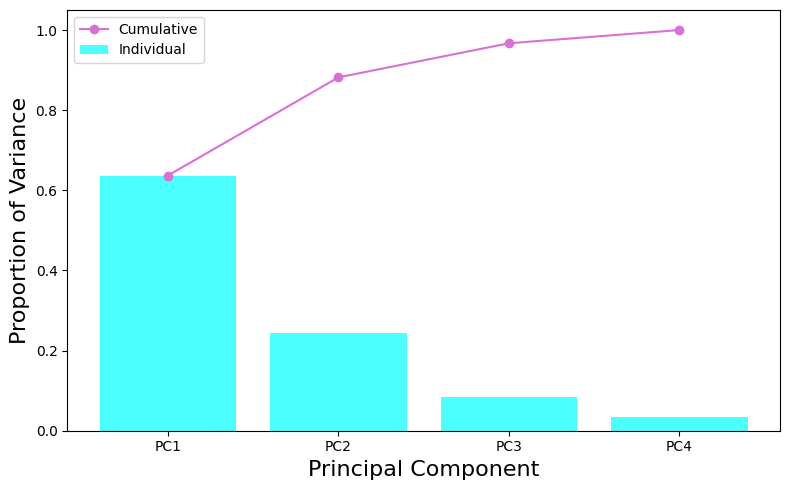

In [501]:
# Scree plot
fig, ax = plt.subplots(figsize=(8, 5))

# Individual explained variance as bars
ax.bar(pca_tbl["PC"], pca_tbl["explained_var"], label="Individual", alpha=0.7, color='cyan')

# Cumulative explained variance as line with markers
ax.plot(pca_tbl["PC"], pca_tbl["cum_explained"], marker='o', color='orchid', label="Cumulative")

# Titles and labels
# ax.set_title("PCA Scree Plot (standardised variables)")
ax.set_xlabel("Principal Component", fontsize=16)
ax.set_ylabel("Proportion of Variance", fontsize=16)
ax.legend()

# Optional: make layout tight
plt.tight_layout()

# Save figure
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "pca_scree_plot.png")
plt.savefig(downloads_path, dpi=300)
plt.show()

In [ ]:
# ==========================
# Time series diagnostics (pooled series across stations)
# ==========================

# Build pooled monthly series: median across stations for each month
pooled = df.groupby("ds")[["rain","rain_log1p","sun","lowest_max","highest_min"]].median().reset_index()
pooled = pooled.sort_values("ds").reset_index(drop=True)

# Raw series plots (2x2)
raw_fig = make_subplots(rows=2, cols=2, subplot_titles=[
    "Pooled median: Rain (mm)", "Pooled median: Sun (MJ/m²)",
    "Pooled median: Highest min (°C)", "Pooled median: Lowest max (°C)"
])
raw_map = [("rain","Rain (mm)"),("sun","Sun (MJ/m²)"),("highest_min","Highest min (°C)"),("lowest_max","Lowest max (°C)")]
for i,(v,label) in enumerate(raw_map):
    r=i//2+1; c=i%2+1
    raw_fig.add_trace(go.Scatter(x=pooled["ds"], y=pooled[v], mode="lines", showlegend=False), row=r,col=c)
    raw_fig.update_yaxes(title_text=label, row=r,col=c)
raw_fig.update_layout(height=650, width=1000, title="Raw pooled time series (median across stations)")
save_fig(raw_fig, "ts_raw_series_pooled")

# Rolling mean and std (windows in months)
# These windows are chosen to mimic the report's rolling mean/std figures.
ROLL_WINDOWS = [20, 50, 100]

def rolling_stats(series, w):
    return series.rolling(w, min_periods=w).mean(), series.rolling(w, min_periods=w).std(ddof=1)

# Plot rolling mean + std for each variable (4 figures)
for v,label in raw_map:
    s = pooled.set_index("ds")[v]
    fig = make_subplots(rows=1, cols=2, subplot_titles=[f"Rolling mean ({label})", f"Rolling std ({label})"])
    for w in ROLL_WINDOWS:
        m, sd = rolling_stats(s, w)
        fig.add_trace(go.Scatter(x=m.index, y=m.values, mode="lines", name=f"mean {w}"), row=1,col=1)
        fig.add_trace(go.Scatter(x=sd.index, y=sd.values, mode="lines", name=f"std {w}"), row=1,col=2)
    fig.update_layout(height=350, width=1000, title=f"Rolling statistics for {label}")
    save_fig(fig, f"ts_rolling_{v}")

# Simple seasonal-trend decomposition (STL-like, minimal dependencies)
def simple_decompose(series, trend_window=120):
    """Return DataFrame with columns: trend, seasonal, resid."""
    name = series.name if series.name is not None else "y"
    df_ = series.reset_index().rename(columns={name:"y"})
    df_["month"] = df_["ds"].dt.month

    # Seasonal component: month-of-year median
    seasonal_map = df_.groupby("month")["y"].median()
    df_["seasonal"] = df_["month"].map(seasonal_map)

    # Trend: rolling mean of seasonally adjusted series
    df_["adj"] = df_["y"] - df_["seasonal"]
    df_["trend"] = df_["adj"].rolling(trend_window, min_periods=trend_window).mean()

    # Residual
    df_["resid"] = df_["y"] - df_["seasonal"] - df_["trend"]
    return df_.set_index("ds")[["trend","seasonal","resid"]]

# Decomposition plots (one per variable)
for v,label in raw_map:
    s = pooled.set_index("ds")[v].dropna()
    decomp = simple_decompose(s, trend_window=120)  # 10-year trend window (monthly data)
    fig = make_subplots(rows=4, cols=1, shared_xaxes=True,
                        subplot_titles=[f"Raw ({label})","Trend (10y rolling mean of seasonally adjusted)","Seasonal (month-of-year median)","Residual"])
    fig.add_trace(go.Scatter(x=s.index, y=s.values, mode="lines", showlegend=False), row=1,col=1)
    fig.add_trace(go.Scatter(x=decomp.index, y=decomp["trend"], mode="lines", showlegend=False), row=2,col=1)
    fig.add_trace(go.Scatter(x=decomp.index, y=decomp["seasonal"], mode="lines", showlegend=False), row=3,col=1)
    fig.add_trace(go.Scatter(x=decomp.index, y=decomp["resid"], mode="markers", marker=dict(size=2), showlegend=False), row=4,col=1)
    fig.update_layout(height=900, width=1000, title=f"Simple seasonal-trend decomposition: {label}")
    save_fig(fig, f"ts_decomposition_{v}")

# Power spectral density (periodogram via FFT)
def periodogram(series):
    y = np.asarray(series.dropna(), dtype=float)
    y = y - y.mean()
    n = len(y)
    fft = np.fft.rfft(y)
    power = (np.abs(fft)**2) / n
    freq = np.fft.rfftfreq(n, d=1.0)  # d=1 month
    return freq[1:], power[1:]  # drop zero frequency

def seasonal_diff(series, lag=12):
    return series.diff(lag)

psd_fig = make_subplots(rows=2, cols=2, subplot_titles=[
    "PSD: Rain (log1p, seasonal diff)", "PSD: Sun (seasonal diff)",
    "PSD: Highest min (seasonal diff)", "PSD: Lowest max (seasonal diff)"
])
psd_vars = [("rain_log1p","Rain (log1p)"),("sun","Sun"),("highest_min","Highest min"),("lowest_max","Lowest max")]
for i,(v,label) in enumerate(psd_vars):
    r=i//2+1; c=i%2+1
    s = pooled.set_index("ds")[v]
    y = seasonal_diff(s, 12).dropna()
    f, p = periodogram(y)
    psd_fig.add_trace(go.Scatter(x=f, y=p, mode="lines", showlegend=False), row=r,col=c)
    psd_fig.update_xaxes(title_text="frequency (cycles/month)", row=r,col=c)
    psd_fig.update_yaxes(title_text="power", row=r,col=c)

psd_fig.update_layout(height=650, width=1000, title="Power spectral density after seasonal differencing")
save_fig(psd_fig, "ts_psd_all_vars")

print("Annual cycle frequency (cycles/month):", 1/12)


In [ ]:
import matplotlib.pyplot as plt
ROLL_WINDOWS = [20, 50, 100]
colors = ["orchid", "mediumpurple", "cyan"]  # one color per window

for v, label in raw_map:
    s = pooled.set_index("ds")[v]
    
    # Create figure with 2 subplots (mean, std)
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    for i, w in enumerate(ROLL_WINDOWS):
        m, sd = rolling_stats(s, w)
        
        # Plot rolling mean
        axs[0].plot(m.index, m.values, color=colors[i], label=f"mean {w}")
        
        # Plot rolling std
        axs[1].plot(sd.index, sd.values, color=colors[i], label=f"std {w}")
    
    # Set titles and labels
    axs[0].set_title(f"Rolling mean ({label})")
    axs[0].set_xlabel("Date")
    axs[0].set_ylabel(label)
    axs[0].legend()
    
    axs[1].set_title(f"Rolling std ({label})")
    axs[1].set_xlabel("Date")
    axs[1].set_ylabel(label)
    axs[1].legend()
    
    # plt.suptitle(f"Rolling statistics for {label}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", f"rolling_{v}.png")
    plt.savefig(downloads_path, dpi=300)
    # Save figure
    # plt.savefig(f"rolling_{v}.png", dpi=300)
    plt.show()
    # plt.close(fig)

In [ ]:
# Define colors
colors = ["orchid", "mediumpurple", "cyan", "darkblue"]

# Raw map: variable name and label
raw_map = [
    ("rain", "Precipitation (mm)"),
    ("sun", "Sun (MJ/m²)"),
    ("highest_min", "Highest min (°C)"),
    ("lowest_max", "Lowest max (°C)")
]

# Create 2x2 figure
fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# Flatten axs array for easy indexing
axs = axs.flatten()

# Plot each variable
for i, (v, label) in enumerate(raw_map):
    axs[i].plot(pooled["ds"], pooled[v], color=colors[i])
    axs[i].set_title(f"Pooled median: {label}")
    axs[i].set_xlabel("Date")
    axs[i].set_ylabel(label)
    axs[i].grid(True)

# Overall figure title
fig.suptitle("Raw Pooled Time Series (median across stations)", fontsize=16)

# Save figure
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "raw.png")
plt.savefig(downloads_path, dpi=300)
plt.show()

In [ ]:

# Define colors for each component
colors = {
    "raw": "orchid",
    "trend": "mediumpurple",
    "seasonal": "cyan",
    "resid": "darkblue"
}

# Decomposition plots (one per variable)
for v, label in raw_map:
    s = pooled.set_index("ds")[v].dropna()
    decomp = simple_decompose(s, trend_window=120)  # 10-year trend window (monthly data)

    # Create 4 vertically stacked subplots with shared x-axis
    fig, axes = plt.subplots(4, 1, sharex=True, figsize=(10, 9))

    # 1 — Raw
    axes[0].plot(s.index, s.values, color=colors["raw"])
    axes[0].set_title(f"Raw ({label})")

    # 2 — Trend
    axes[1].plot(decomp.index, decomp["trend"], color=colors["trend"])
    axes[1].set_title("Trend (10y rolling mean of seasonally adjusted)")

    # 3 — Seasonal
    axes[2].plot(decomp.index, decomp["seasonal"], color=colors["seasonal"])
    axes[2].set_title("Seasonal (monthly median)")

    # 4 — Residual
    axes[3].scatter(decomp.index, decomp["resid"], s=4, color=colors["resid"])
    axes[3].set_title("Residual")

    # Overall title and layout
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle

    # Save figure per variable
    downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", f"decomp_{v}.png",)

    plt.savefig(downloads_path, dpi=300)


In [502]:
# Power spectral density (periodogram via FFT)
def periodogram(series):
    y = np.asarray(series.dropna(), dtype=float)
    y = y - y.mean()
    n = len(y)
    fft = np.fft.rfft(y)
    power = (np.abs(fft)**2) / n
    freq = np.fft.rfftfreq(n, d=1.0)  # d=1 month
    return freq[1:], power[1:]  # drop zero frequency

def seasonal_diff(series, lag=12):
    return series.diff(lag)

psd_fig = make_subplots(rows=2, cols=2, subplot_titles=[
    "PSD: Rain (log1p, seasonal diff)", "PSD: Sun (seasonal diff)",
    "PSD: Highest min (seasonal diff)", "PSD: Lowest max (seasonal diff)"
])
psd_vars = [("rain_log1p","Rain (log1p)"),("sun","Sun"),("highest_min","Highest min"),("lowest_max","Lowest max")]
for i,(v,label) in enumerate(psd_vars):
    r=i//2+1; c=i%2+1
    s = pooled.set_index("ds")[v]
    y = seasonal_diff(s, 12).dropna()
    f, p = periodogram(y)
    psd_fig.add_trace(go.Scatter(x=f, y=p, mode="lines", showlegend=False), row=r,col=c)
    psd_fig.update_xaxes(title_text="frequency (cycles/month)", row=r,col=c)
    psd_fig.update_yaxes(title_text="power", row=r,col=c)

# psd_fig.update_layout(height=650, width=1000, title="Power spectral density after seasonal differencing")
save_fig(psd_fig, "ts_psd_all_vars")

'outputs_evt_study/ts_psd_all_vars.html'

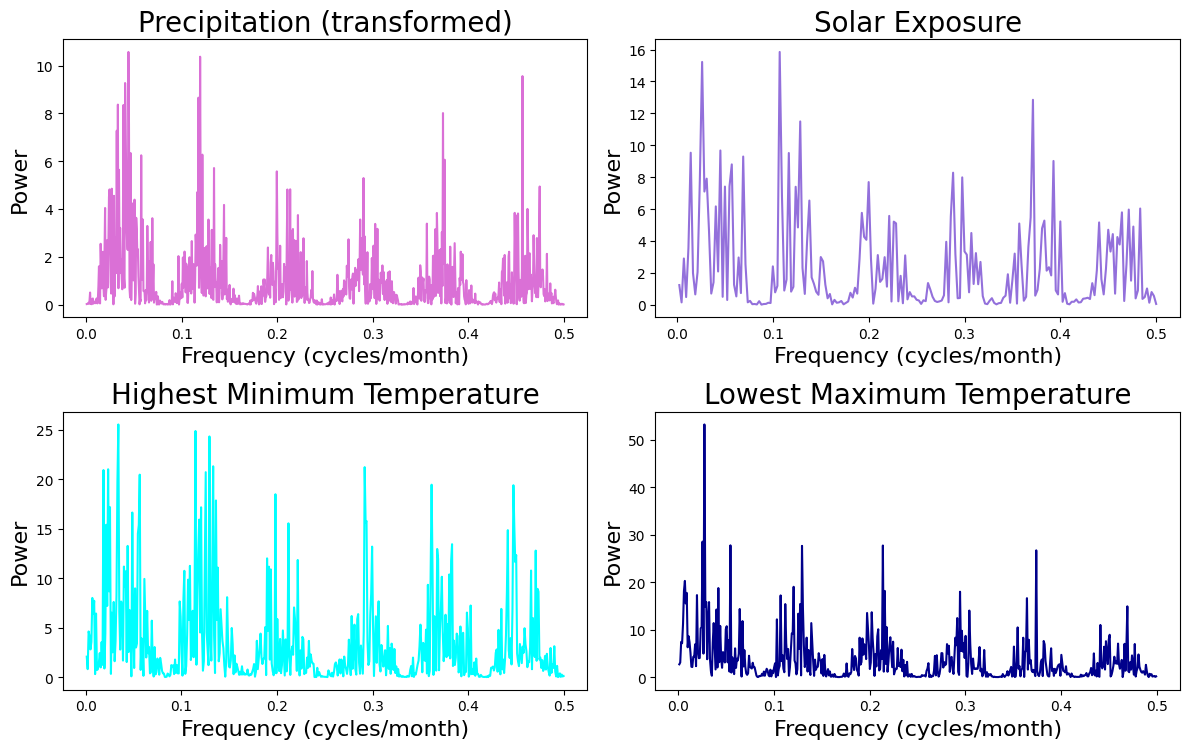

In [505]:
# Power spectral density (periodogram via FFT)
def periodogram(series):
    y = np.asarray(series.dropna(), dtype=float)
    y = y - y.mean()
    n = len(y)
    fft = np.fft.rfft(y)
    power = (np.abs(fft)**2) / n
    freq = np.fft.rfftfreq(n, d=1.0)
    return freq[1:], power[1:]

def seasonal_diff(series, lag=12):
    return series.diff(lag)

# Variables, titles, and colors
psd_vars = [
    ("rain_log1p", "Precipitation (transformed)", "orchid"),
    ("sun", "Solar Exposure", "mediumpurple"),
    ("highest_min", "Highest Minimum Temperature", "cyan"),
    ("lowest_max", "Lowest Maximum Temperature", "darkblue")
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (v, title, color) in enumerate(psd_vars):
    s = pooled.set_index("ds")[v]
    y = seasonal_diff(s, 12).dropna()
    f, p = periodogram(y)

    axes[i].plot(f, p, color=color)
    axes[i].set_title(title, fontsize=20)
    axes[i].set_xlabel("Frequency (cycles/month)", fontsize=16)
    axes[i].set_ylabel("Power", fontsize=16)

# fig.suptitle("Power Spectral Density After Seasonal Differencing", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("ts_psd_all_vars.png", dpi=300)
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "psd.png")

plt.savefig(downloads_path, dpi=300)
plt.show()

## Stationarity, trends, and change-points (diagnostics)

### Why we do this
Many standard time-series models (ARIMA/SARIMA/VAR) assume some form of **stationarity** after differencing and/or removing seasonality.

A weakly stationary series has:
\[
\mathbb{E}[X_t] = \mu \quad\text{constant}, \qquad \mathrm{Var}(X_t)=\sigma^2 \quad\text{constant},
\]
and an autocovariance that depends only on the lag, not on time.

Australian climate series often have:
- strong **seasonality** (period 12 months),
- possible **long-term trends** (e.g. warming),
- possible **regime changes** (change-points).

### What we compute (simple, readable diagnostics)
1. **Trend slope** by station (OLS on annual means): gives units like °C/year.
2. **Pettitt test** (nonparametric change-point) on annual means.
3. **ADF-style unit root regression statistic** (we report the t-statistic for the lag-1 level term):
   \[
   \Delta z_t = \alpha + \gamma z_{t-1} + \varepsilon_t.
   \]
   Strongly negative \(\gamma\) suggests stationarity; near 0 suggests a unit root.

> These diagnostics are not “final truth”, but they justify why we do seasonal differencing and/or trend modelling later.



In [532]:
# ==========================
# Stationarity / trend / change-point diagnostics (TARGET variable)
# ==========================

def to_working_scale(y, target):
    """Transform to a modelling-friendly scale (monotone)."""
    if target == "rain":
        return np.log1p(y)
    return y

def from_working_scale(x, target):
    if target == "rain":
        return np.expm1(x)
    return x

# Build a TARGET-only panel
ycol = TARGET
work_col = TARGET + "_work"

tmp = df[["station","ds","Year","Month","lat","lon",ycol]].copy()
tmp[work_col] = to_working_scale(tmp[ycol], TARGET)

# Annual means by station (working scale)
annual = tmp.dropna(subset=[work_col]).groupby(["station","Year"]).agg(
    y_mean=(work_col,"mean"),
    lat=("lat","first"),
    lon=("lon","first"),
).reset_index()

# OLS slope y_mean ~ a + b*Year
def ols_slope(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x0 = x - x.mean()
    b = np.sum(x0*(y-y.mean())) / np.sum(x0**2)
    a = y.mean() - b*x.mean()
    return a, b

# Pettitt change-point test
def pettitt_test(y, years):
    """Return (cp_year, K, p_approx). y is 1D array."""
    y = np.asarray(y, float)
    n = len(y)
    if n < 5:
        return (np.nan, np.nan, np.nan)
    # ranks
    r = pd.Series(y).rank().values
    U = np.zeros(n)
    for t in range(n):
        U[t] = 2*np.sum(r[:t+1]) - (t+1)*(n+1)
    K = np.max(np.abs(U))
    t0 = int(np.argmax(np.abs(U)))
    # approximate p-value
    p = 2*np.exp((-6*K**2)/(n**3 + n**2))
    return (int(years[t0]), float(K), float(min(p,1.0)))

trend_rows = []
for st, g in annual.groupby("station"):
    a, b = ols_slope(g["Year"].values, g["y_mean"].values)
    cp_year, K, p = pettitt_test(g["y_mean"].values, g["Year"].values)
    trend_rows.append({
        "station": st,
        "lat": float(g["lat"].iloc[0]),
        "lon": float(g["lon"].iloc[0]),
        "n_years": int(g.shape[0]),
        "trend_slope_per_year_(working_scale)": b,
        "pettitt_cp_year": cp_year,
        "pettitt_K": K,
        "pettitt_p_approx": p
    })

trend_tbl = pd.DataFrame(trend_rows).sort_values("station")
display(trend_tbl.head())
save_table(trend_tbl, f"stationarity_trend_changepoint_{TARGET}")

# ADF-style t-statistic (no p-values; simple diagnostic)
def adf_tstat(series):
    """ADF regression: Δy_t = α + γ y_{t-1} + ε_t. Return t-stat for γ."""
    y = pd.Series(series).dropna().values.astype(float)
    if len(y) < 30:
        return np.nan
    dy = np.diff(y)
    y_lag = y[:-1]
    X = np.column_stack([np.ones(len(y_lag)), y_lag])
    # OLS
    beta = np.linalg.lstsq(X, dy, rcond=None)[0]
    resid = dy - X@beta
    s2 = np.sum(resid**2) / (len(dy)-2)
    XtX_inv = np.linalg.inv(X.T@X)
    se_gamma = np.sqrt(s2 * XtX_inv[1,1])
    gamma = beta[1]
    return float(gamma / se_gamma)

# Compute ADF t-stat per station on:
#   (a) deseasonalised series z_t = x_t - median(x|month)
#   (b) seasonal-differenced series w_t = x_t - x_{t-12}
adf_rows = []
for st, g in tmp.sort_values("ds").groupby("station"):
    gg = g.dropna(subset=[work_col]).copy()
    if gg.empty:
        continue
    gg["month"] = gg["ds"].dt.month
    mo_med = gg.groupby("month")[work_col].median()
    gg["z"] = gg[work_col] - gg["month"].map(mo_med)
    gg["w"] = gg["z"].diff(12)

    adf_rows.append({
        "station": st,
        "adf_tstat_deseasonalised": adf_tstat(gg["z"]),
        "adf_tstat_seasonal_diff": adf_tstat(gg["w"])
    })

adf_tbl = pd.DataFrame(adf_rows).sort_values("station")
display(adf_tbl.head())
save_table(adf_tbl, f"stationarity_adf_tstats_{TARGET}")




,station,lat,lon,n_years,trend_slope_per_year_(working_scale),pettitt_cp_year,pettitt_K,pettitt_p_approx
0,9225,-31.92,115.87,34,-0.015876,2021,115.0,0.281380
1,13011,-26.13,126.58,74,0.002534,1986,392.0,0.211874
2,14015,-12.42,130.89,86,0.004105,1967,611.0,0.061547
3,23034,-34.95,138.52,72,-0.005238,2001,269.0,0.635001
4,23373,-34.48,139.01,31,-0.023386,2017,82.0,0.538608


,station,adf_tstat_deseasonalised,adf_tstat_seasonal_diff
0,9225,-18.326986,-17.797190
1,13011,-23.922463,-24.527314
2,14015,-28.046543,-27.197253
3,23034,-25.163453,-26.052196
4,23373,-18.288852,-19.089765


'outputs_evt_study/stationarity_adf_tstats_rain.csv'

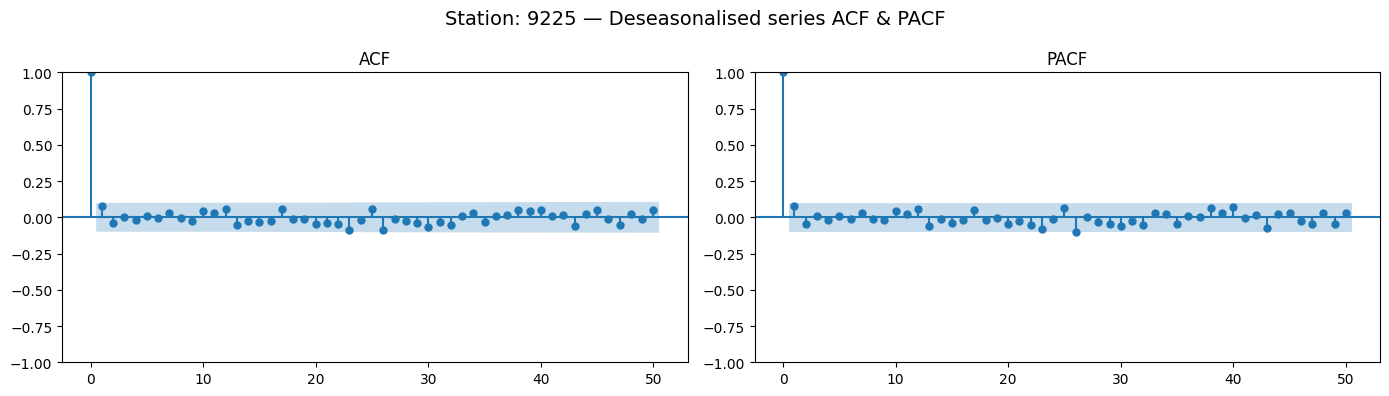

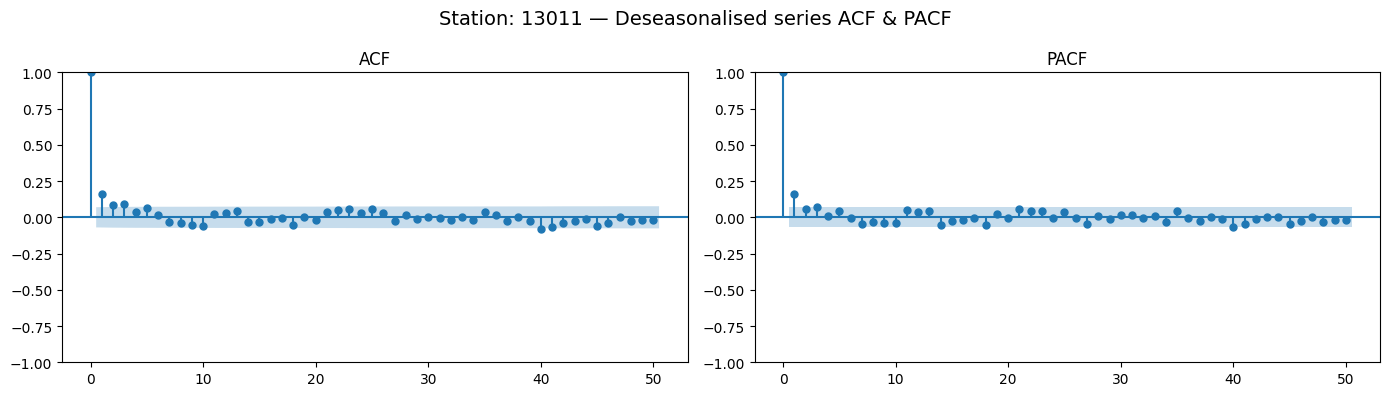

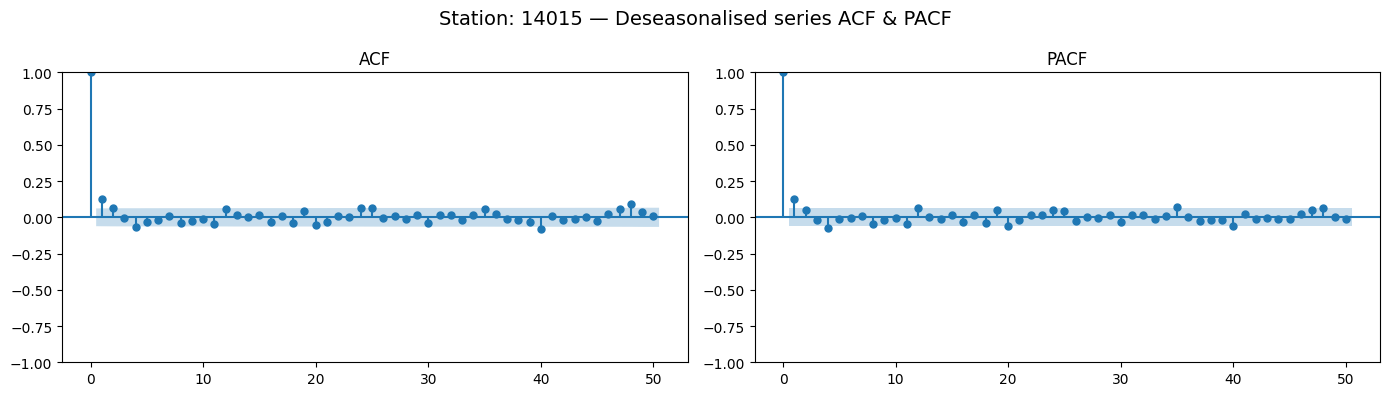

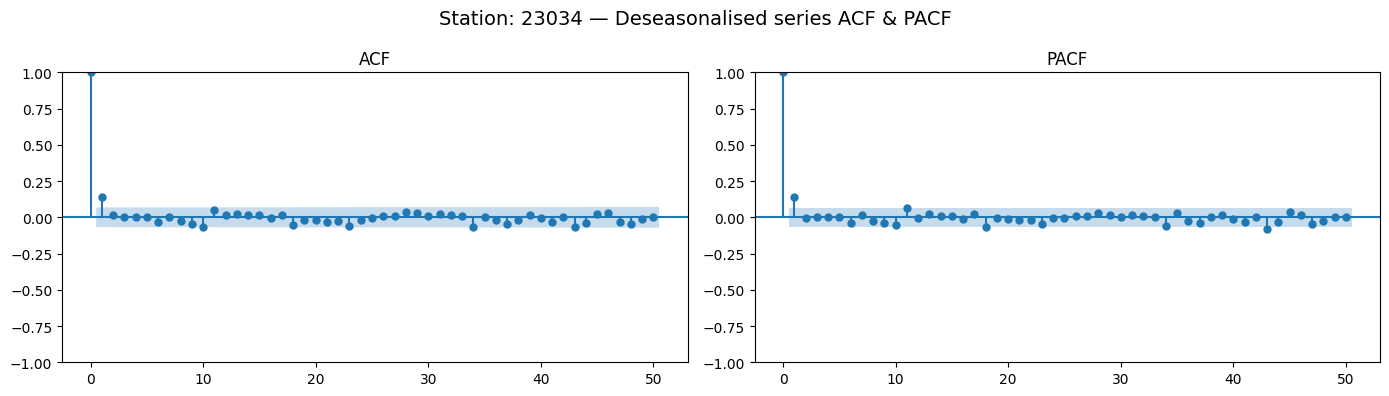

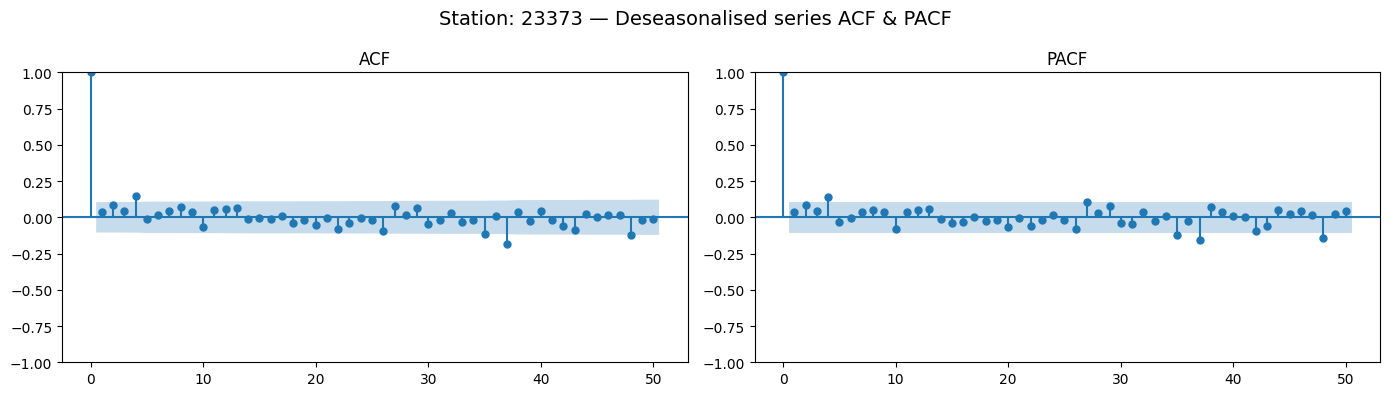

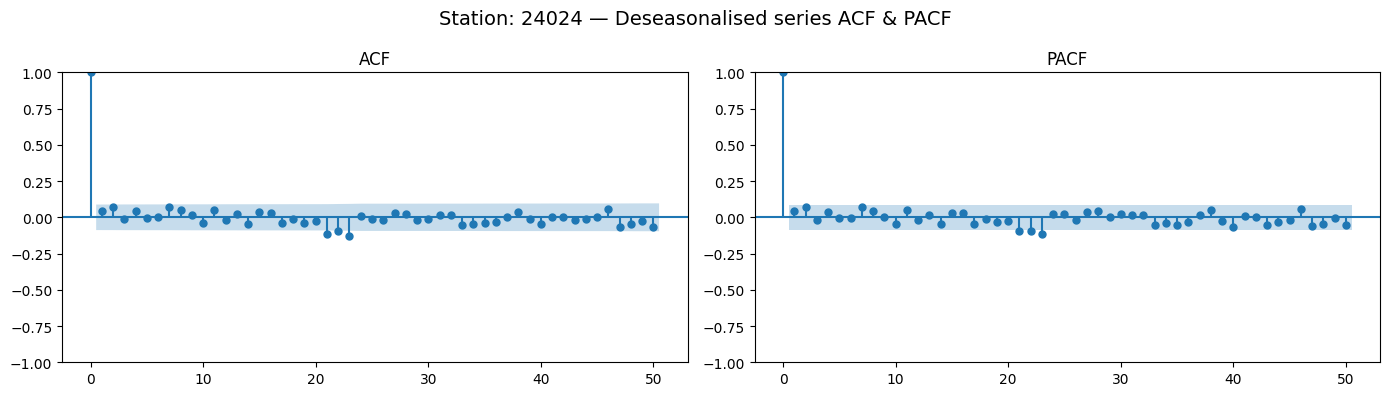

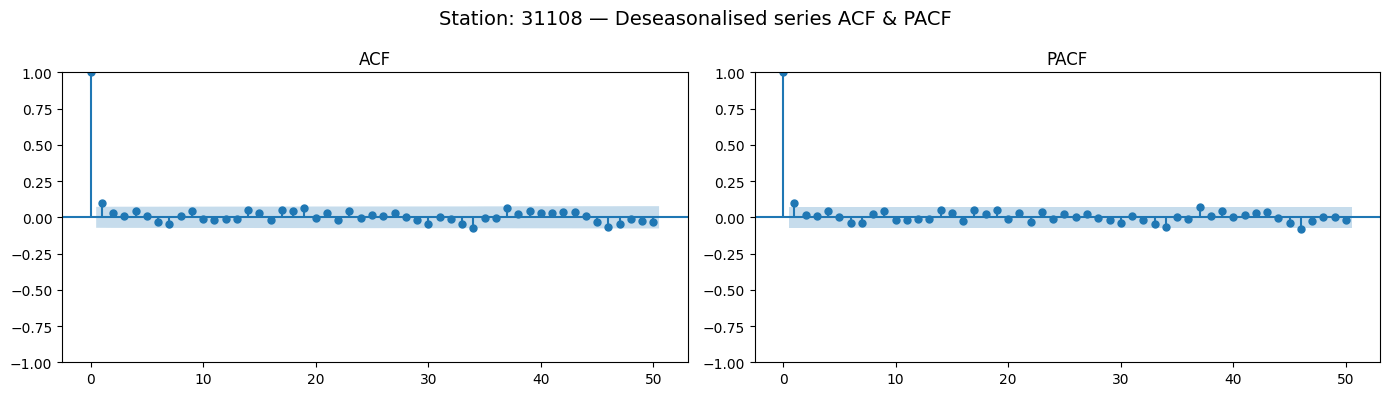

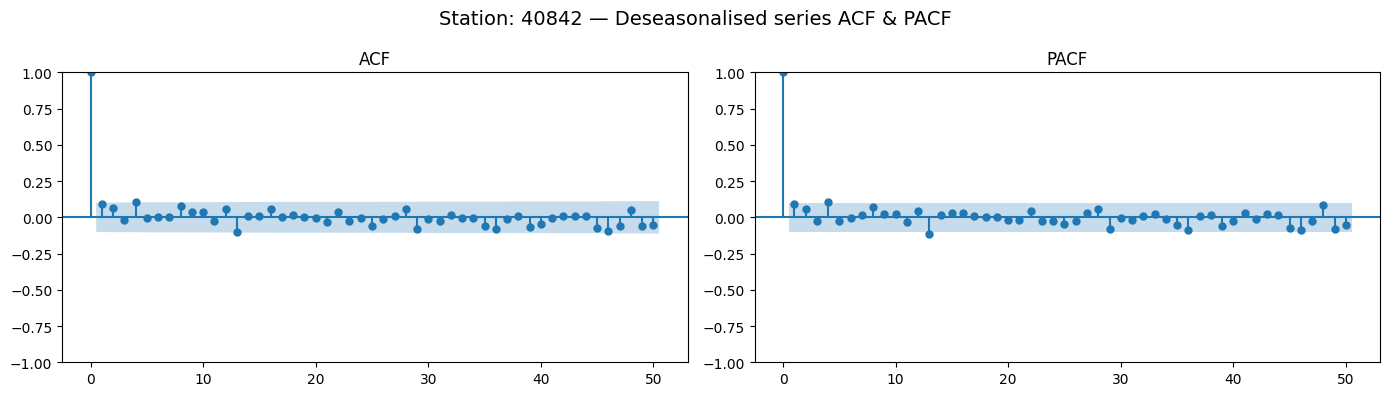

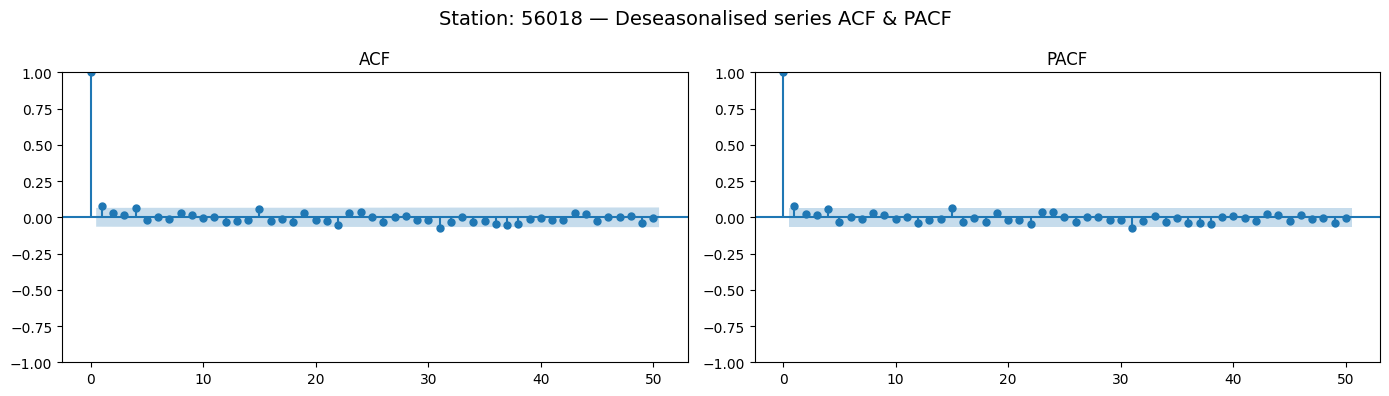

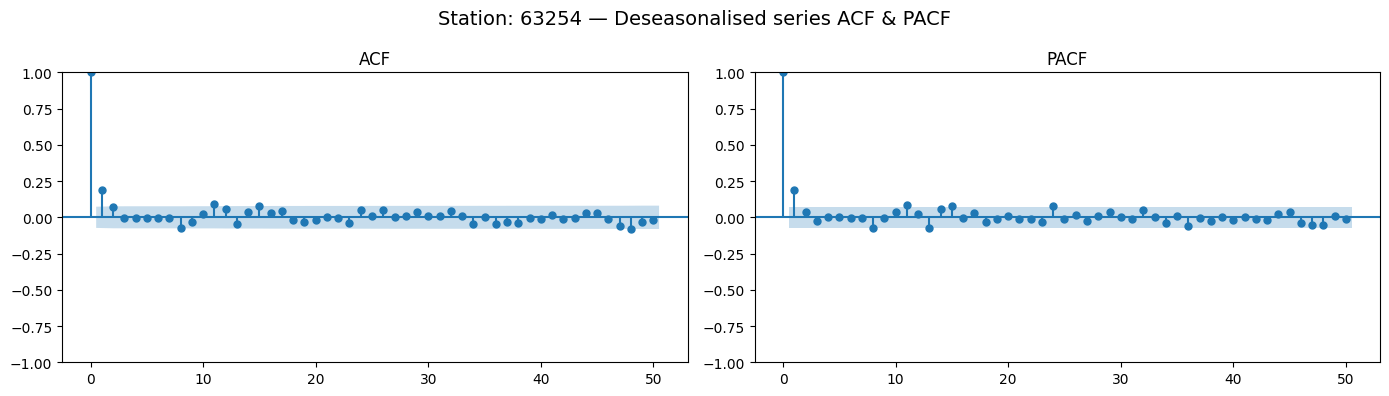

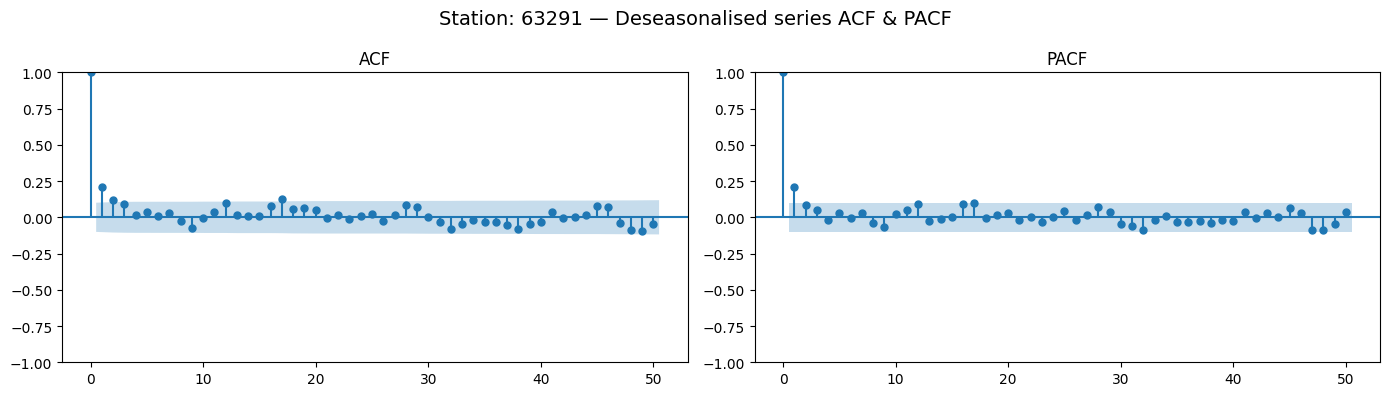

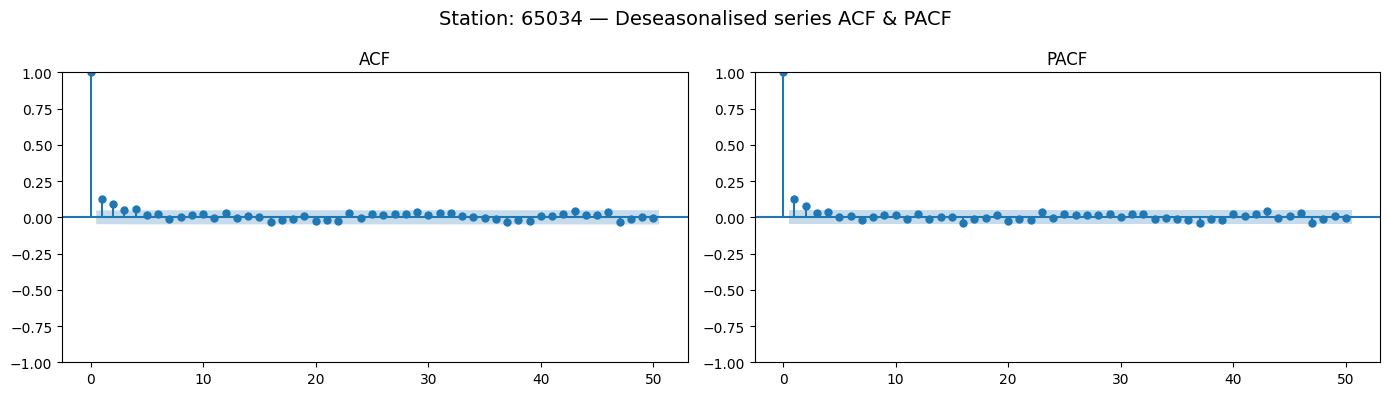

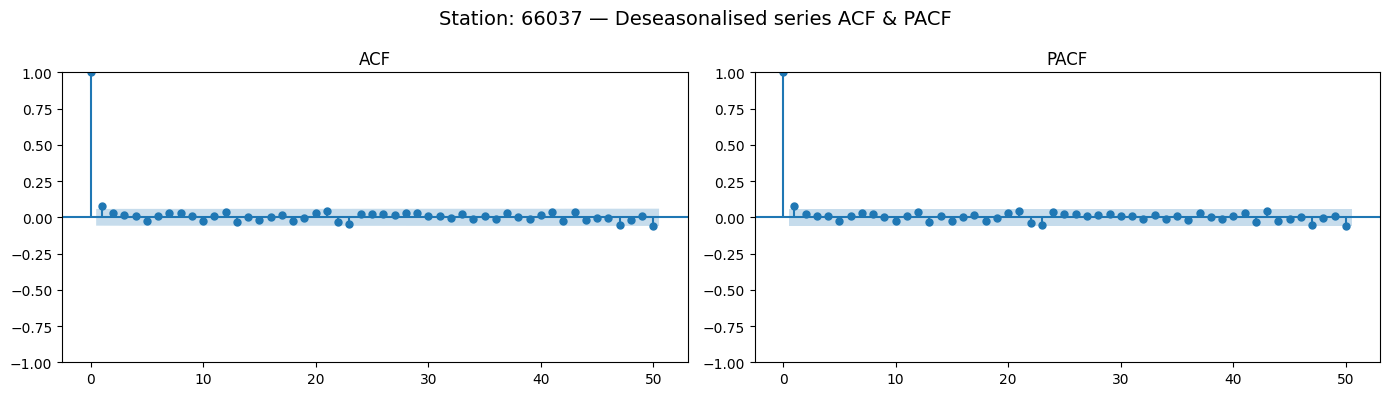

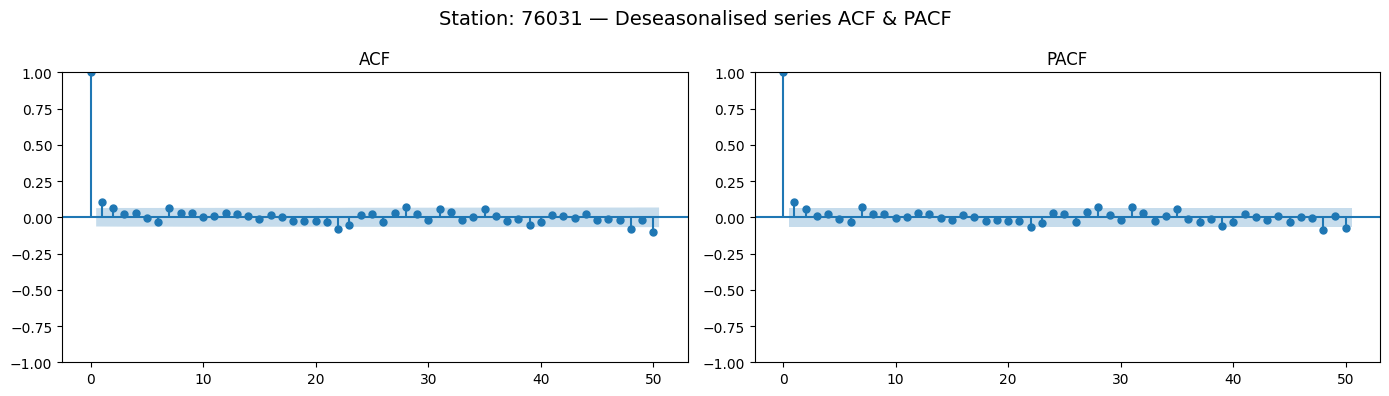

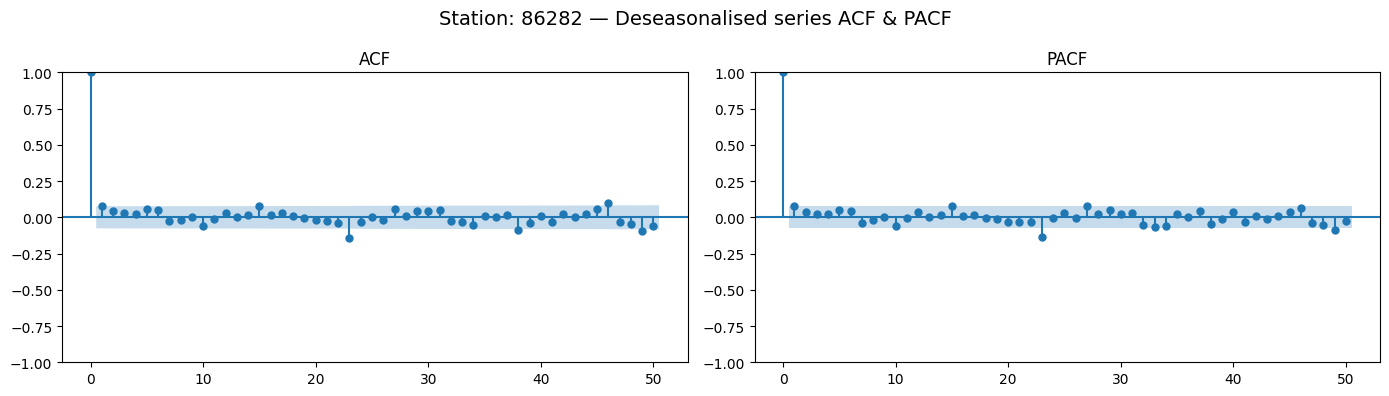

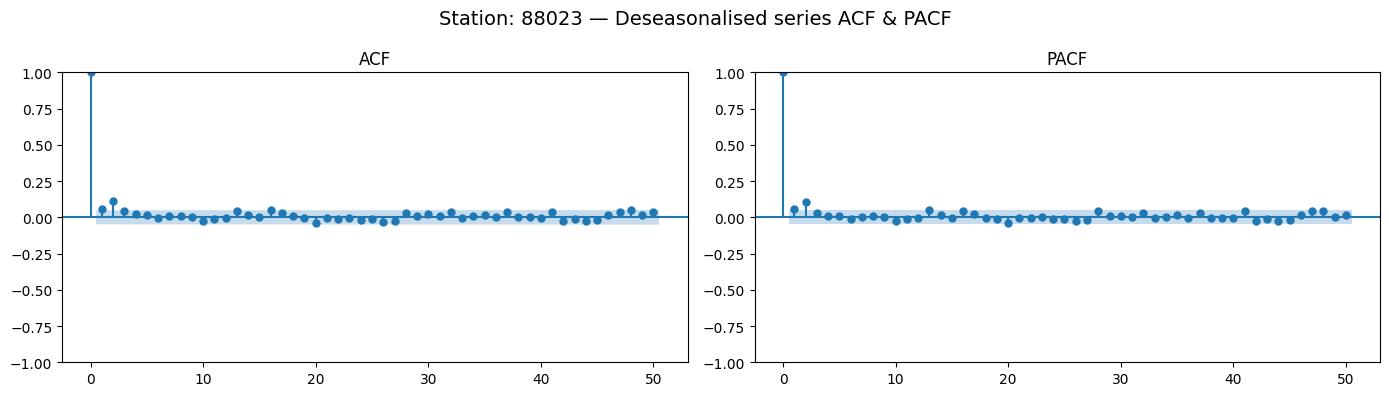

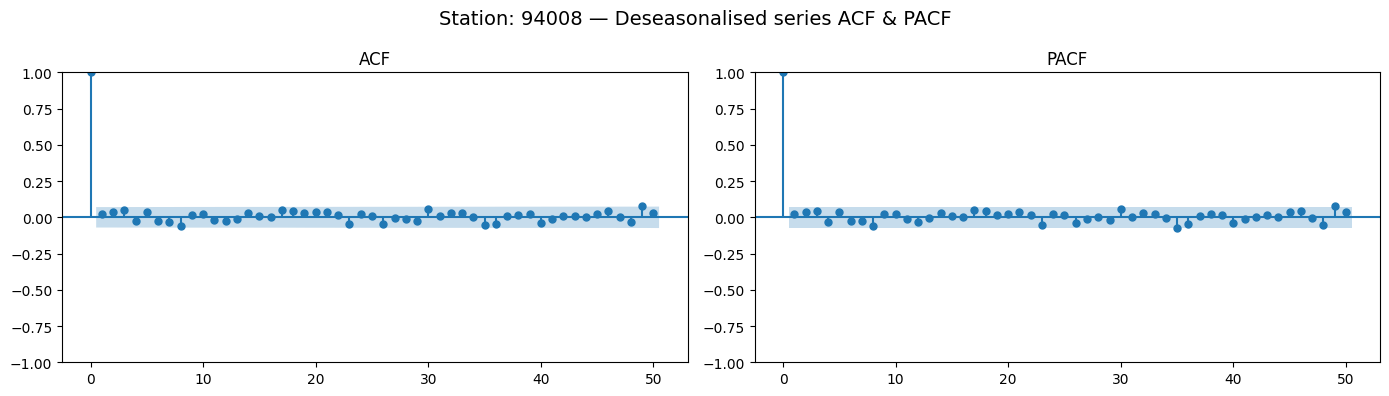

In [533]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Optional: choose a specific station to plot, or loop over all
station_to_plot = None  # set to a station name or keep None for all

for st, g in tmp.sort_values("ds").groupby("station"):
    gg = g.dropna(subset=[work_col]).copy()
    if gg.empty:
        continue

    # Deseasonalise
    gg["month"] = gg["ds"].dt.month
    mo_med = gg.groupby("month")[work_col].median()
    gg["z"] = gg[work_col] - gg["month"].map(mo_med)

    # If a specific station is selected
    if station_to_plot and st != station_to_plot:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Station: {st} — Deseasonalised series ACF & PACF", fontsize=14)

    plot_acf(gg["z"].dropna(), ax=axes[0], lags=50)
    axes[0].set_title("ACF")

    plot_pacf(gg["z"].dropna(), ax=axes[1], lags=50, method='ywm')
    axes[1].set_title("PACF")

    plt.tight_layout()
    plt.show()

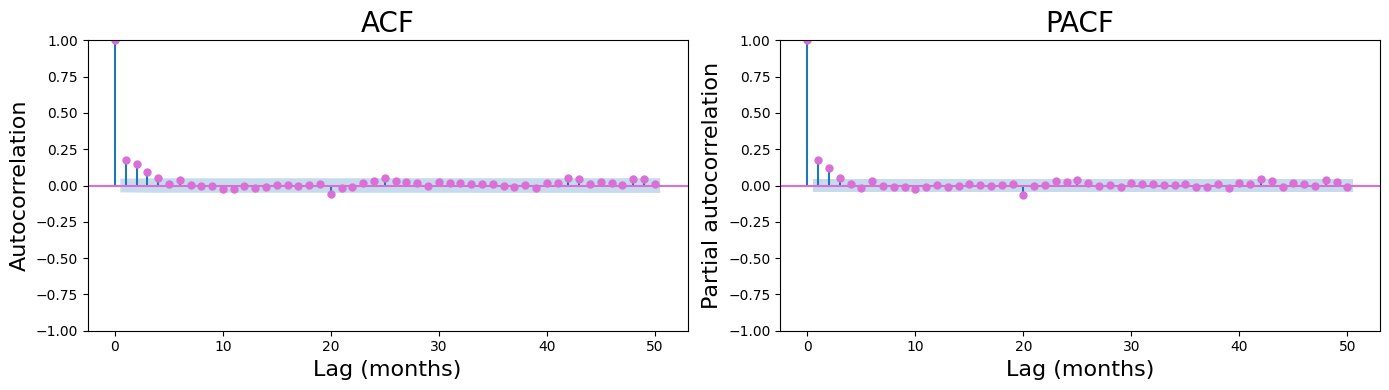

In [535]:
# Make a copy and deseasonalise per station
tmp_ds = tmp.dropna(subset=[work_col]).copy()
tmp_ds["month"] = tmp_ds["ds"].dt.month

# Compute month-wise median per station
tmp_ds["month_median"] = tmp_ds.groupby(["station","month"])[work_col].transform("median")

# Deseasonalised series per station
tmp_ds["z"] = tmp_ds[work_col] - tmp_ds["month_median"]

# Average across stations per date
avg_z = tmp_ds.groupby("ds")["z"].mean()

# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(avg_z, ax=axes[0], lags=50, color='orchid')
axes[0].set_title("ACF", fontsize=20)
axes[0].set_xlabel("Lag (months)", fontsize=16)
axes[0].set_ylabel("Autocorrelation", fontsize=16)

plot_pacf(avg_z, ax=axes[1], lags=50, method='ywm', color='orchid')
axes[1].set_title("PACF", fontsize=20)
axes[1].set_xlabel("Lag (months)", fontsize=16)
axes[1].set_ylabel("Partial autocorrelation", fontsize=16)

plt.tight_layout()

downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "acf_r.png")

plt.savefig(downloads_path, dpi=300)
plt.show()

In [ ]:
# Quick map of trend slopes (working scale)
fig = go.Figure()
fig.add_trace(go.Scattergeo(
    
    lon=trend_tbl["lon"],
    lat=trend_tbl["lat"],
    text=trend_tbl["station"].astype(str),
    mode="markers",
    marker=dict(size=10, color=trend_tbl["trend_slope_per_year_(working_scale)"], colorbar=dict(title="trend slope")),
))
fig.update_geos(scope="world", lataxis_range=[-45,-10], lonaxis_range=[110,155])
fig.update_layout(title=f"Trend slope map (working scale) — TARGET={TARGET}")
save_fig(fig, f"stationarity_trend_map_{TARGET}")

## Forecasting models (naive → bulk → extremes)

We build a small “model zoo” so we can compare:

### Naive baselines
1. **Persistence**
   \[
   \hat x_{t+h} = x_t
   \]
2. **Seasonal naive (period 12)**
   \[
   \hat x_{t+h} = x_{t+h-12}
   \]
3. **Pooled median** (one constant for everything)
4. **Climatology** (station × month median)

### Bulk model (typical behaviour)
For each station \(s\) and calendar month \(m\), estimate training quantiles:
\[
\hat Q_{s,m}(q),\quad q \in \{0.25,0.50,0.75\}.
\]
The “bulk median forecast” is \(\hat Q_{s,m}(0.50)\). The IQR band is \([\hat Q_{s,m}(0.25), \hat Q_{s,m}(0.75)]\).

### ARIMA-style baseline (simple)
We use a very light seasonal AR(1) baseline:
- remove climatology,
- seasonal difference at lag 12,
- fit \(w_t = c + \phi w_{t-1} + \varepsilon_t\).

This mimics a SARIMA-type approach but stays dependency-light.

### Extremes model (POT–GPD)
We model tail behaviour of *standardised residuals*.

Let \(x_t\) be the value on the **working scale** (for rain we use \(x_t=\log(1+\mathrm{rain}_t)\)).

Define a robust scale via IQR:
\[
\sigma_{s,m} = \hat Q_{s,m}(0.75) - \hat Q_{s,m}(0.25),
\qquad
r_t = \frac{x_t - \hat Q_{s,m}(0.50)}{\max(\sigma_{s,m}, \sigma_{\min})}.
\]

Choose a high threshold \(u\) (e.g. 95th percentile of \(r_t\) in training), then exceedances
\[
y = r-u \mid r > u
\]
are modelled with a **Generalised Pareto distribution (GPD)**:
\[
\mathbb{P}(Y \le y) = 1 - \left(1 + \xi\frac{y}{\beta}\right)^{-1/\xi}, \qquad y\ge 0.
\]

From this we compute a tail quantile (e.g. \(q=0.99\)) and map it back to \(x\) and finally to the original units.

---

### Practical note: upper vs lower tail
If `TAIL="lower"` we model extremes of \(-x\) (so the same code fits both tails).



In [ ]:


EXT_Q_X = EXT_Q_UPPER if TAIL == "upper" else EXT_Q_LOWER

TAIL_PROB = (1 - EXT_Q_X) if TAIL == "upper" else EXT_Q_X

EXT_Q_R = 1 - TAIL_PROB

print("EXT_Q_X (original quantile) =", EXT_Q_X)
print("TAIL_PROB =", TAIL_PROB)
print("EXT_Q_R (residual quantile) =", EXT_Q_R)

def make_target_panel(df_all, target):
    """Return a station×month panel for the chosen target with working-scale values."""
    out = df_all[["station","ds","Month","lat","lon","alt_m","east_west","coastal", target]].copy()
    out = out.rename(columns={target:"y"})
    out["x"] = to_working_scale(out["y"], target)
    return out.sort_values(["station","ds"]).reset_index(drop=True)

def complete_monthly_grid(panel):
    """Ensure each station has a continuous monthly timeline (no missing months)."""
    frames = []
    for st, g in panel.groupby("station"):
        dmin, dmax = g["ds"].min(), g["ds"].max()
        full_ds = pd.date_range(dmin, dmax, freq="MS")
        grid = pd.DataFrame({"station": st, "ds": full_ds})
        grid["Month"] = grid["ds"].dt.month

        gg = g.drop(columns=["Month"])
        grid = grid.merge(gg, on=["station","ds"], how="left")

        for c in ["lat","lon","alt_m","east_west","coastal"]:
            if c in grid.columns:
                val = g[c].dropna().iloc[0]
                grid[c] = grid[c].fillna(val)

        frames.append(grid)
    out = pd.concat(frames, ignore_index=True)
    return out.sort_values(["station","ds"]).reset_index(drop=True)

def fit_station_month_quantiles(train_obs, q_list):
    """Fit station×month empirical quantiles on training OBSERVED data."""
    out = train_obs[["station","Month","x"]].dropna().copy()
    grp = out.groupby(["station","Month"])["x"]
    quant = {}
    for q in q_list:
        quant[f"q{int(100*q)}"] = grp.quantile(q)
    quant = pd.DataFrame(quant).reset_index()
    return quant

def add_quantiles(df_in, quant_tbl):
    """Merge quantiles onto a DataFrame."""
    out = df_in.merge(quant_tbl, on=["station","Month"], how="left")
    return out

def impute_x_by_station_month(df_full, train_obs):
    """Impute missing x values using training station×month medians (leak-free)."""
    # station×month medians (training observed)
    sm = train_obs.groupby(["station","Month"])["x"].median()
    s = train_obs.groupby("station")["x"].median()
    g = train_obs["x"].median()

    out = df_full.copy()
    out["x_model"] = out["x"]
    out["is_imputed"] = out["x_model"].isna()

    for i in out.index[out["is_imputed"]]:
        st = out.at[i,"station"]
        m  = out.at[i,"Month"]
        if (st,m) in sm.index and not pd.isna(sm.loc[(st,m)]):
            out.at[i,"x_model"] = float(sm.loc[(st,m)])
        elif st in s.index and not pd.isna(s.loc[st]):
            out.at[i,"x_model"] = float(s.loc[st])
        else:
            out.at[i,"x_model"] = float(g)

    return out

# ---- Naive models ----

def predict_persistence(train, test):
    """All future months get the last training value (x_model)."""
    last_val = train.groupby("station")["x_model"].last()
    out = test[["station","ds"]].copy()
    out["pred_persist"] = out["station"].map(last_val)
    return out

def predict_seasonal_naive(train, test, horizon=12):
    """Seasonal naive: predict x_{t-12}. If missing, fallback later."""
    hist = train[["station","ds","x_model"]].copy()
    lag = hist.copy()
    lag["ds"] = lag["ds"] + pd.DateOffset(months=12)
    lag = lag.rename(columns={"x_model":"pred_seasonal12"})
    out = test[["station","ds"]].merge(lag, on=["station","ds"], how="left")
    return out

def predict_pooled_median(train_obs, test):
    """One constant prediction for all stations/dates."""
    med = float(train_obs["x"].median())
    out = test[["station","ds"]].copy()
    out["pred_pooled"] = med
    return out

# ---- ARIMA-style baseline: seasonal AR(1) on seasonal differences ----

def fit_ar1(y):
    """Fit AR(1): y_t = c + phi*y_{t-1} + eps. Returns (c, phi)."""
    y = np.asarray(pd.Series(y).dropna(), float)
    if len(y) < 30:
        return (0.0, 0.0)
    y1 = y[1:]
    y0 = y[:-1]
    X = np.column_stack([np.ones(len(y0)), y0])
    beta = np.linalg.lstsq(X, y1, rcond=None)[0]
    c, phi = float(beta[0]), float(beta[1])
    return c, phi

def predict_sar1(train, test, q50_col="q50", horizon=12):
    """Seasonal AR(1) baseline on seasonally differenced anomalies.

    Steps for each station:
    1) anomaly a_t = x_model - q50(month)
    2) seasonal difference w_t = a_t - a_{t-12}
    3) fit AR1 on w_t
    4) forecast w_{t+1..t+H}
    5) reconstruct a_{t+h} = w_{t+h} + a_{t+h-12} (works cleanly for H<=12)
    6) x_hat = q50(month) + a_hat
    """
    out_rows = []
    for st, g in train.groupby("station"):
        g = g.sort_values("ds").copy()
        if q50_col not in g.columns:
            continue
        # anomaly
        g["a"] = g["x_model"] - g[q50_col]
        # seasonal difference
        g["w"] = g["a"] - g["a"].shift(12)
        w = g["w"].dropna()
        if len(w) < 30:
            c, phi = (0.0, 0.0)
        else:
            c, phi = fit_ar1(w.values)

        # last w value at end of training
        w_last = float(w.values[-1]) if len(w) > 0 else 0.0

        # Build a lookup for a_{t-12} values (needed for reconstruction)
        a_lookup = g.set_index("ds")["a"]

        # Forecast for this station
        gtest = test.loc[test["station"]==st].sort_values("ds")
        for h, row in enumerate(gtest.itertuples(index=False), start=1):
            # recursive forecast of w
            if h == 1:
                w_hat = c + phi*w_last
            else:
                w_hat = c + phi*w_hat

            # need a at ds-12 (must be in training history for H<=12)
            ds = row.ds
            ds_lag = ds - pd.DateOffset(months=12)
            if ds_lag in a_lookup.index:
                a_lag = float(a_lookup.loc[ds_lag])
            else:
                a_lag = 0.0

            # reconstruct anomaly and then x
            q50m = float(getattr(row, q50_col))
            a_hat = w_hat + a_lag
            x_hat = q50m + a_hat

            out_rows.append({"station": st, "ds": ds, "pred_ar1": x_hat})

    out = pd.DataFrame(out_rows)
    return out

# ---- EVT: POT-GPD on standardised residuals ----

def fit_gpd_mom(excess):
    """Method-of-moments GPD fit for exceedances (excess >= 0). Returns (xi, beta)."""
    x = np.asarray(excess, float)
    if len(x) < 10:
        return (np.nan, np.nan)
    m = x.mean()
    v = x.var(ddof=1)
    if v <= 0 or np.isnan(v):
        return (np.nan, np.nan)
    xi = 0.5*(1 - (m*m)/v)
    # beta = m*(1-xi)   (from m = beta/(1-xi))
    beta = m*(1 - xi)
    return (float(xi), float(beta))

def gpd_quantile(u, p_u, xi, beta, q):
    """Quantile of r at probability q given threshold u and exceedance prob p_u."""
    # We only use this for q close to 1 (extremes)
    tail = 1 - q
    if tail <= 0:
        return np.inf
    if p_u <= 0:
        return np.nan
    # xi -> 0 limit
    if abs(xi) < 1e-6:
        return float(u + beta * math.log(p_u / tail))
    return float(u + (beta/xi) * ((p_u / tail)**xi - 1))

def fit_evt_params(train, p0=P0, sigma_floor=1e-6):
    """Fit EVT parameters per station using training data with fitted q25/q50/q75."""
    rows = []
    for st, g in train.groupby("station"):
        g = g.dropna(subset=["x","q25","q50","q75"]).copy()
        if g.empty:
            continue
        # robust scale by IQR
        sigma = (g["q75"] - g["q25"]).values
        sigma = np.maximum(sigma, sigma_floor)

        # residual 'extremeness' r (always upper tail in r-space)
        if TAIL == "upper":
            r = (g["x"].values - g["q50"].values) / sigma
        else:
            r = (g["q50"].values - g["x"].values) / sigma

        # threshold u
        u = float(np.quantile(r, p0))
        exceed = r[r > u]
        excess = exceed - u
        p_u = float(len(exceed) / len(r))

        # fit GPD
        xi, beta = fit_gpd_mom(excess)

        # simple stability guards (avoid blow-ups)
        if not np.isfinite(xi) or not np.isfinite(beta) or beta <= 0:
            xi = 0.0
            beta = float(np.mean(excess)) if len(excess) > 0 else np.nan

        # clip xi to a reasonable range for stability
        xi = float(np.clip(xi, -0.5, 0.5))

        rows.append({"station": st, "u": u, "p_u": p_u, "xi": xi, "beta": beta})

    return pd.DataFrame(rows)

def predict_extreme_quantile(df_in, evt_params):
    """Compute EVT-based extreme quantile for each row (needs q25/q50/q75)."""
    out = df_in.merge(evt_params, on="station", how="left")
    sigma = np.maximum(out["q75"] - out["q25"], 1e-6)

    # compute r_q at EXT_Q_R
    r_q = []
    for u,p_u,xi,beta in zip(out["u"], out["p_u"], out["xi"], out["beta"]):
        if any(pd.isna([u,p_u,xi,beta])):
            r_q.append(np.nan)
        else:
            r_q.append(gpd_quantile(u, p_u, xi, beta, EXT_Q_R))
    r_q = np.asarray(r_q, float)

    if TAIL == "upper":
        x_ext = out["q50"].values + sigma.values * r_q
    else:
        x_ext = out["q50"].values - sigma.values * r_q

    out["evt_ext_q"] = x_ext
    return out[["station","ds","evt_ext_q","u","p_u","xi","beta"]]


EXT_Q_X (original quantile) = 0.01
TAIL_PROB = 0.01
EXT_Q_R (residual quantile) = 0.99


## Backtesting (rolling-origin) + diagnostics plots

We use a **rolling-origin** design:

- Choose a sequence of training cutoffs (origins) near the end of the dataset.
- For each origin:
  - train on all data up to that month,
  - forecast the next `HORIZON` months,
  - compare predictions to observations.

This matches how long-horizon forecasting is actually used.

We report:
- MAE for several baselines,
- calibration of the extreme quantile (tail event rate vs expected),
- pinball loss for the extreme quantile,
- and a “usual vs extreme” split of error.



In [491]:
# ==========================
# Rolling-origin backtest runner
# ==========================

panel0 = make_target_panel(df, TARGET)
panel = complete_monthly_grid(panel0)

# Pick an example station automatically (most observed values for TARGET)
if EXAMPLE_STATION is None:
    obs_counts = panel.groupby("station")["y"].apply(lambda s: s.notna().sum())
    EXAMPLE_STATION = int(obs_counts.sort_values(ascending=False).index[0])
print("Example station =", EXAMPLE_STATION)

# Backtest origins (end of training). We mimic the report: last fold ends at ds_max - HORIZON months.
ds_max = panel["ds"].max()
max_origin = ds_max - pd.DateOffset(months=HORIZON)
origins = [max_origin - pd.DateOffset(months=12*i) for i in range(N_FOLDS)][::-1]

print("Backtest origins:")
for o in origins:
    print(" -", o.date())

all_metrics = []
all_preds = []

for origin in origins:
    train_end = origin
    test_end = origin + pd.DateOffset(months=HORIZON)

    train_full = panel.loc[panel["ds"] <= train_end].copy()
    test_full  = panel.loc[(panel["ds"] > train_end) & (panel["ds"] <= test_end)].copy()

    # Observed training data for model fitting
    train_obs = train_full.dropna(subset=["x"]).copy()

    # Fit station×month quantiles (bulk model)
    q_list = [0.25, 0.50, 0.75, EXT_Q_X]
    quant_tbl = fit_station_month_quantiles(train_obs, q_list=q_list)

    q_ext_name = f"q{int(round(100*EXT_Q_X))}"
    if q_ext_name in quant_tbl.columns:
        quant_tbl = quant_tbl.rename(columns={q_ext_name: "bulk_ext_q"})

    # Merge quantiles onto train/test
    train_full = add_quantiles(train_full, quant_tbl)
    test_full  = add_quantiles(test_full, quant_tbl)

    # Impute missing x values (for naive + AR baseline)
    train_full = impute_x_by_station_month(train_full, train_obs)
    test_full  = impute_x_by_station_month(test_full, train_obs)

    # Naive predictions
    p_persist = predict_persistence(train_full, test_full)
    p_snaive  = predict_seasonal_naive(train_full, test_full)
    p_pool    = predict_pooled_median(train_obs, test_full)

    # AR1 baseline
    p_ar1 = predict_sar1(train_full, test_full, q50_col="q50", horizon=HORIZON)

    # EVT params fitted on training OBSERVED points (need q25/q50/q75)
    train_evt = add_quantiles(train_obs, quant_tbl)
    evt_params = fit_evt_params(train_evt, p0=P0)

    # EVT extreme quantile predictions on test months
    evt_pred = predict_extreme_quantile(test_full, evt_params)

    # Assemble prediction table for this fold
    pred = test_full[["station","ds","Month","lat","lon","y","x","q25","q50","q75","bulk_ext_q"]].copy()
    pred = pred.merge(p_persist, on=["station","ds"], how="left")
    pred = pred.merge(p_snaive,  on=["station","ds"], how="left")
    pred = pred.merge(p_pool,    on=["station","ds"], how="left")
    pred = pred.merge(p_ar1,     on=["station","ds"], how="left")
    pred = pred.merge(evt_pred,  on=["station","ds"], how="left")

    pred["origin"] = train_end

    # Evaluate only where y is observed in the test window
    ev = pred.dropna(subset=["y"]).copy()

    # Convert working-scale predictions back to original units
    ev["y_q25"] = from_working_scale(ev["q25"], TARGET)
    ev["y_q50"] = from_working_scale(ev["q50"], TARGET)
    ev["y_q75"] = from_working_scale(ev["q75"], TARGET)

    for col in ["pred_persist","pred_seasonal12","pred_pooled","pred_ar1"]:
        ev["y_"+col] = from_working_scale(ev[col], TARGET)

    ev["y_bulk_ext_q"] = from_working_scale(ev["bulk_ext_q"], TARGET)
    ev["y_evt_ext_q"]  = from_working_scale(ev["evt_ext_q"], TARGET)

    # Metrics
    y_true = ev["y"].values

    m = {
        "origin": train_end.date().isoformat(),
        "n_obs": int(len(ev)),
        "MAE_persistence": mae(y_true, ev["y_pred_persist"]),
        "MAE_seasonal12": mae(y_true, ev["y_pred_seasonal12"]),
        "MAE_pooled": mae(y_true, ev["y_pred_pooled"]),
        "MAE_climatology": mae(y_true, ev["y_q50"]),
        "MAE_ar1": mae(y_true, ev["y_pred_ar1"]),
        "RMSE_climatology": rmse(y_true, ev["y_q50"]),
        "IQR_coverage_(q25,q75)": float(np.mean((y_true >= ev["y_q25"]) & (y_true <= ev["y_q75"]))),
        "Expected_tail_rate": TAIL_PROB,
    }

    # Tail event rate for bulk extreme and EVT extreme
    if TAIL == "upper":
        m["TailRate_bulk_ext"] = float(np.mean(y_true > ev["y_bulk_ext_q"]))
        m["TailRate_evt_ext"]  = float(np.mean(y_true > ev["y_evt_ext_q"]))
    else:
        m["TailRate_bulk_ext"] = float(np.mean(y_true < ev["y_bulk_ext_q"]))
        m["TailRate_evt_ext"]  = float(np.mean(y_true < ev["y_evt_ext_q"]))

    # Pinball loss for the extreme quantile
    m["Pinball_bulk_ext"] = pinball_loss(y_true, ev["y_bulk_ext_q"], EXT_Q_X)
    m["Pinball_evt_ext"]  = pinball_loss(y_true, ev["y_evt_ext_q"], EXT_Q_X)

    # Usual vs extreme MAE split (using r>u as "extreme")
    sigma = np.maximum(ev["q75"] - ev["q25"], 1e-6).values
    if TAIL == "upper":
        r_obs = (ev["x"].values - ev["q50"].values) / sigma
    else:
        r_obs = (ev["q50"].values - ev["x"].values) / sigma
    extreme = r_obs > ev["u"].values

    if extreme.any():
        m["MAE_bulk_usual"] = mae(y_true[~extreme], ev.loc[~extreme, "y_q50"].values) if (~extreme).any() else np.nan
        m["MAE_bulk_extreme"] = mae(y_true[extreme], ev.loc[extreme, "y_q50"].values)
    else:
        m["MAE_bulk_usual"] = mae(y_true, ev["y_q50"].values)
        m["MAE_bulk_extreme"] = np.nan

    all_metrics.append(m)
    all_preds.append(pred)

# Save backtest outputs
metrics_df = pd.DataFrame(all_metrics)
preds_df = pd.concat(all_preds, ignore_index=True)

display(metrics_df)
save_table(metrics_df, f"backtest_metrics_{TARGET}_{TAIL}")
save_table(preds_df, f"backtest_predictions_{TARGET}_{TAIL}")

print("Saved:", f"backtest_metrics_{TARGET}_{TAIL}.csv", "and", f"backtest_predictions_{TARGET}_{TAIL}.csv")


Example station = 66037
Backtest origins:
 - 2021-02-01
 - 2022-02-01
 - 2023-02-01
 - 2024-02-01
 - 2025-02-01


,origin,n_obs,MAE_persistence,MAE_seasonal12,MAE_pooled,MAE_climatology,MAE_ar1,RMSE_climatology,"IQR_coverage_(q25,q75)",Expected_tail_rate,TailRate_bulk_ext,TailRate_evt_ext,Pinball_bulk_ext,Pinball_evt_ext,MAE_bulk_usual,MAE_bulk_extreme
0,2021-02-01,204,5.861275,2.036765,5.175000,1.371078,2.036448,1.771430,0.495098,0.01,0.034314,0.009804,0.062648,0.052087,1.241885,3.269231
1,2022-02-01,198,6.466162,1.761616,4.958081,1.478535,1.756643,1.959208,0.500000,0.01,0.020202,0.005051,0.055771,0.056112,1.337968,3.868182
2,2023-02-01,192,4.953125,2.093750,5.032292,1.435417,2.092079,1.930383,0.500000,0.01,0.005208,0.000000,0.047437,0.056774,1.378723,4.100000
3,2024-02-01,192,5.665104,1.840104,5.117188,1.887500,1.838104,2.368896,0.375000,0.01,0.010417,0.005208,0.063356,0.066679,1.855319,3.400000
4,2025-02-01,159,6.655975,1.942138,4.828931,1.421384,1.947894,1.803787,0.459119,0.01,0.006289,0.006289,0.050293,0.057180,1.365161,3.600000


Saved: backtest_metrics_lowest_max_lower.csv and backtest_predictions_lowest_max_lower.csv


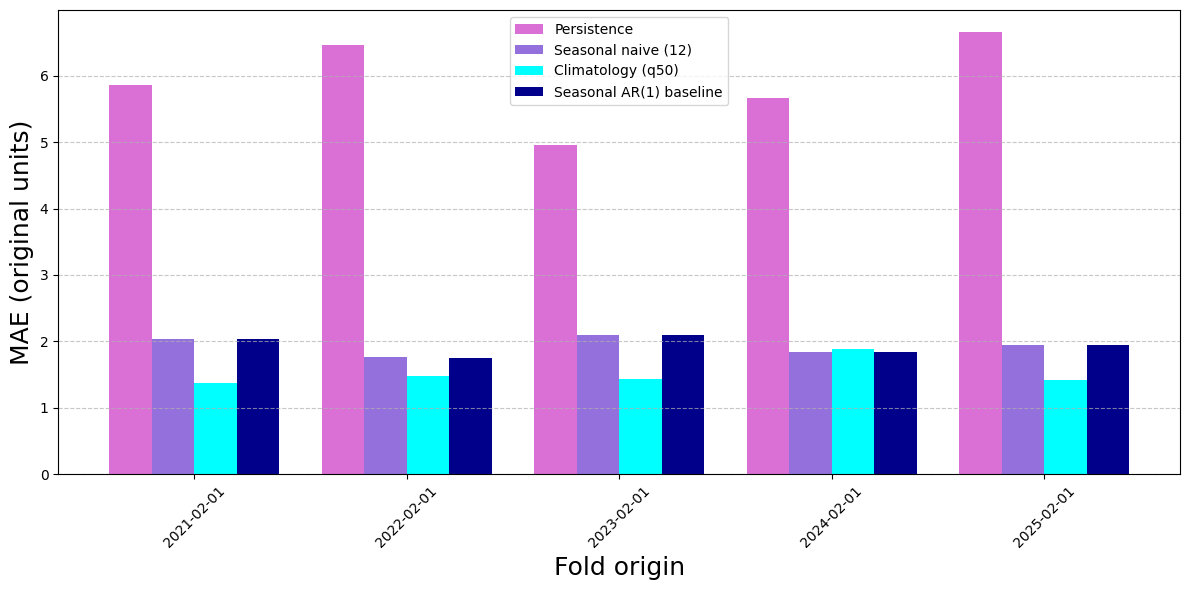

In [492]:
# Define colors for each model (optional, can choose distinct colors)
colors = ["orchid", "mediumpurple", "cyan", "darkblue"]

# Columns and labels
cols_labels = [
    ("MAE_persistence","Persistence"),
    ("MAE_seasonal12","Seasonal naive (12)"),
    ("MAE_climatology","Climatology (q50)"),
    ("MAE_ar1","Seasonal AR(1) baseline"),
]

# Copy df and convert origin to datetime
mae_plot_df = metrics_df.copy()
mae_plot_df["origin"] = pd.to_datetime(mae_plot_df["origin"])

# X positions for folds
x = np.arange(len(mae_plot_df["origin"]))
width = 0.2  # width of each bar

fig, ax = plt.subplots(figsize=(12,6))

# Plot bars
for i, (col, label) in enumerate(cols_labels):
    ax.bar(x + i*width, mae_plot_df[col], width=width, label=label, color=colors[i])

# Labels, title, ticks
ax.set_xlabel("Fold origin", fontsize=18)
ax.set_ylabel("MAE (original units)", fontsize=18)
ax.set_xticks(x + width*1.5)  # center group labels
ax.set_xticklabels(mae_plot_df["origin"].dt.strftime("%Y-%m-%d"), rotation=45)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
# Save figure
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "mae_lm_l.png")
plt.savefig(downloads_path, dpi=300)

In [442]:
# Tail event rate plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=mae_plot_df["origin"], y=mae_plot_df["TailRate_bulk_ext"], mode="lines+markers", name="Bulk extreme quantile"))
fig.add_trace(go.Scatter(x=mae_plot_df["origin"], y=mae_plot_df["TailRate_evt_ext"], mode="lines+markers", name="EVT extreme quantile"))
fig.add_trace(go.Scatter(x=mae_plot_df["origin"], y=[TAIL_PROB]*len(mae_plot_df), mode="lines", name="Expected tail rate"))
fig.update_layout(title=f"Tail event rate calibration — TARGET={TARGET}, tail={TAIL}", xaxis_title="fold origin", yaxis_title="tail event rate")
save_fig(fig, f"backtest_tail_rate_{TARGET}_{TAIL}")


'outputs_evt_study/backtest_tail_rate_rain_upper.html'

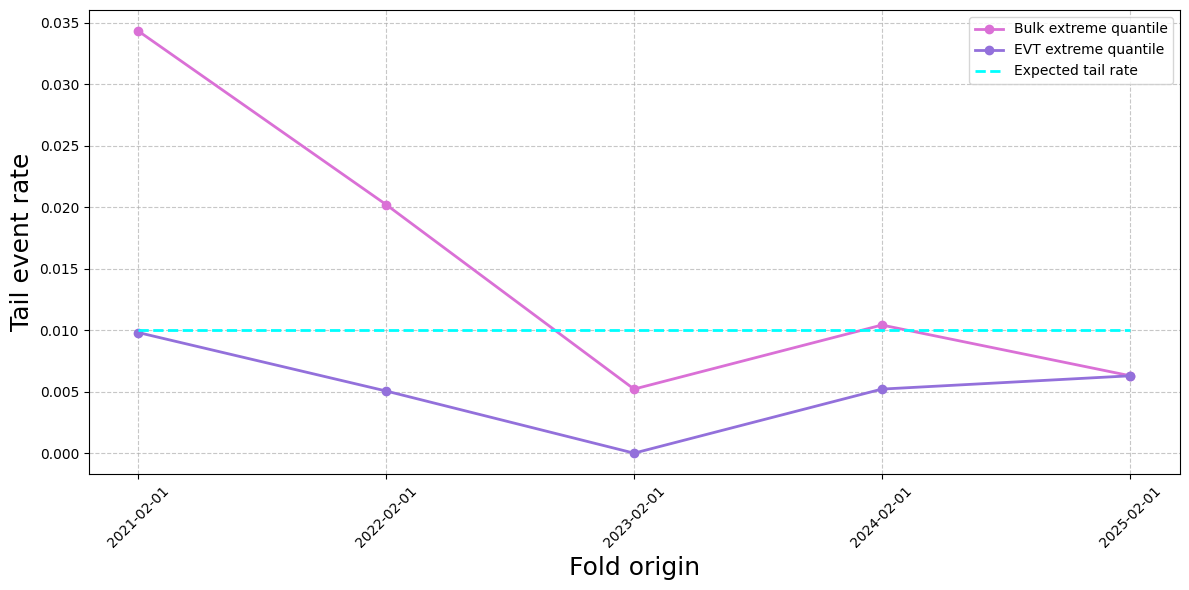

In [493]:
# Copy and ensure origin is datetime
mae_plot_df = metrics_df.copy()
mae_plot_df["origin"] = pd.to_datetime(mae_plot_df["origin"])

# Colors for the two lines
colors = ["orchid", "mediumpurple", "cyan"]  # last one for expected tail rate

fig, ax = plt.subplots(figsize=(12,6))

# Plot Bulk extreme quantile
ax.plot(mae_plot_df["origin"], mae_plot_df["TailRate_bulk_ext"], 
        marker='o', markersize=6, color=colors[0], label="Bulk extreme quantile", linewidth=2)

# Plot EVT extreme quantile
ax.plot(mae_plot_df["origin"], mae_plot_df["TailRate_evt_ext"], 
        marker='o', markersize=6, color=colors[1], label="EVT extreme quantile", linewidth=2)

# Plot expected tail rate
ax.plot(mae_plot_df["origin"], [TAIL_PROB]*len(mae_plot_df),
        color=colors[2], linestyle='--', label="Expected tail rate", linewidth=2)

# Labels, title
ax.set_xlabel("Fold origin", fontsize=18)
ax.set_ylabel("Tail event rate", fontsize=18)
ax.set_xticks(mae_plot_df["origin"])
ax.set_xticklabels(mae_plot_df["origin"].dt.strftime("%Y-%m-%d"), rotation=45)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "tail_lm_l.png")
plt.savefig(downloads_path, dpi=300)

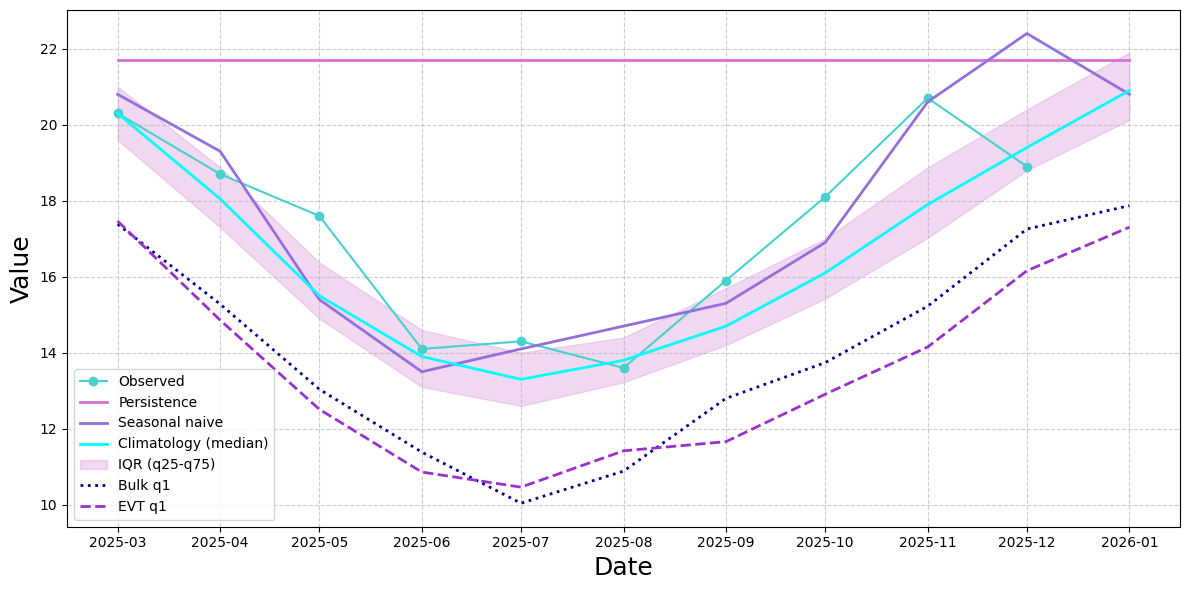

In [494]:
# Latest fold for the example station
latest_origin = pd.to_datetime(metrics_df["origin"]).max()
ex = preds_df.loc[(preds_df["origin"]==latest_origin) & (preds_df["station"]==EXAMPLE_STATION)].copy()
ex = ex.sort_values("ds")

# Inverse-transform for plotting
ex["y_q50"] = from_working_scale(ex["q50"], TARGET)
ex["y_q25"] = from_working_scale(ex["q25"], TARGET)
ex["y_q75"] = from_working_scale(ex["q75"], TARGET)

for col in ["pred_persist","pred_seasonal12","pred_ar1","evt_ext_q","bulk_ext_q"]:
    ex["y_"+col] = from_working_scale(ex[col], TARGET)

# Colors for consistency
colors = {
    "Observed": "mediumturquoise",
    "Persistence": "orchid",
    "Seasonal naive": "mediumpurple",
    "Climatology": "cyan",
    "IQR": "plum",
    "Bulk extreme": "darkblue",
    "EVT extreme": "darkorchid"
}

fig, ax = plt.subplots(figsize=(12,6))

# Observed
ax.plot(ex["ds"], ex["y"], marker='o', color=colors["Observed"], label="Observed", linewidth=1.5)

# Baselines / forecasts
ax.plot(ex["ds"], ex["y_pred_persist"], color=colors["Persistence"], label="Persistence", linewidth=2)
ax.plot(ex["ds"], ex["y_pred_seasonal12"], color=colors["Seasonal naive"], label="Seasonal naive", linewidth=2)
ax.plot(ex["ds"], ex["y_q50"], color=colors["Climatology"], label="Climatology (median)", linewidth=2)

# IQR band (q25-q75)
ax.fill_between(ex["ds"], ex["y_q25"], ex["y_q75"], color=colors["IQR"], alpha=0.4, label="IQR (q25-q75)")

# Extreme quantiles
ax.plot(ex["ds"], ex["y_bulk_ext_q"], color=colors["Bulk extreme"], linestyle=':', label=f"Bulk q{int(100*EXT_Q_X)}", linewidth=2)
ax.plot(ex["ds"], ex["y_evt_ext_q"], color=colors["EVT extreme"], linestyle='--', label=f"EVT q{int(100*EXT_Q_X)}", linewidth=2)

# Labels, title
ax.set_xlabel("Date", fontsize=18)
ax.set_ylabel("Value", fontsize=18)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "fold_lm_l.png")
plt.savefig(downloads_path, dpi=300)

## EVT diagnostics (threshold sensitivity + return levels)

EVT is powerful but **sensitive to the threshold choice**. For the chosen `TARGET` and `TAIL`, we produce:

1. **Threshold sensitivity plot**: fitted shape \(\xi\) vs threshold quantile (and number of exceedances).
2. **Mean residual life (MRL)** plot: \(\mathbb{E}[r-u \mid r>u]\) vs \(u\). A roughly linear MRL region supports a GPD tail.
3. **Return levels** (example station): estimate the \(T\)-year return level and a bootstrap confidence interval.

These are “thesis-grade” additions because they justify the EVT choices rather than treating EVT as a black box.



In [495]:
# ==========================
# EVT diagnostics (on full data) for the example station
# ==========================

panel_full = complete_monthly_grid(make_target_panel(df, TARGET))
obs_full = panel_full.dropna(subset=["x"]).copy()

# Fit full climatology quantiles (q25,q50,q75) for standardisation
quant_full = fit_station_month_quantiles(obs_full, q_list=[0.25,0.5,0.75])
panel_full = add_quantiles(panel_full, quant_full)

# Build residual series r for the example station
g = panel_full.loc[(panel_full["station"]==EXAMPLE_STATION)].dropna(subset=["x","q25","q50","q75"]).copy()
sigma = np.maximum(g["q75"] - g["q25"], 1e-6).values
if TAIL == "upper":
    r = (g["x"].values - g["q50"].values) / sigma
else:
    r = (g["q50"].values - g["x"].values) / sigma

# Threshold sensitivity: xi vs threshold quantile
rows = []
for q0 in THRESH_GRID:
    u = float(np.quantile(r, q0))
    excess = (r[r>u] - u)
    xi, beta = fit_gpd_mom(excess)
    rows.append({"threshold_quantile": q0, "u": u, "n_exceed": int(len(excess)), "xi": xi, "beta": beta})

sens = pd.DataFrame(rows)
display(sens)

fig = make_subplots(rows=1, cols=2, subplot_titles=["Shape xi vs threshold quantile","Number of exceedances"])
fig.add_trace(go.Scatter(x=sens["threshold_quantile"], y=sens["xi"], mode="lines+markers", name="xi"), row=1,col=1)
fig.add_trace(go.Bar(x=sens["threshold_quantile"], y=sens["n_exceed"], name="n_exceed"), row=1,col=2)
fig.update_layout(title=f"EVT threshold sensitivity — station {EXAMPLE_STATION} — TARGET={TARGET}, tail={TAIL}")
save_fig(fig, f"evt_threshold_sensitivity_station_{EXAMPLE_STATION}_{TARGET}_{TAIL}")

# Mean residual life (MRL) plot
# Choose a grid of u values as quantiles of r
mrl_q = np.linspace(0.80, 0.98, 15)
mrl_rows = []
for q0 in mrl_q:
    u = float(np.quantile(r, q0))
    exc = r[r>u] - u
    mrl_rows.append({"q": q0, "u": u, "mean_excess": float(np.mean(exc)) if len(exc)>0 else np.nan, "n_exc": int(len(exc))})

mrl = pd.DataFrame(mrl_rows)

fig = go.Figure()
fig.add_trace(go.Scatter(x=mrl["u"], y=mrl["mean_excess"], mode="lines+markers", name="MRL"))
fig.update_layout(title=f"Mean residual life plot — station {EXAMPLE_STATION} — TARGET={TARGET}, tail={TAIL}",
                  xaxis_title="threshold u (on residual r scale)", yaxis_title="mean excess E[r-u | r>u]")
save_fig(fig, f"evt_mrl_station_{EXAMPLE_STATION}_{TARGET}_{TAIL}")

# Fit EVT at the chosen P0 threshold (on r series)
u0 = float(np.quantile(r, P0))
excess0 = r[r>u0] - u0
xi0, beta0 = fit_gpd_mom(excess0)
p_u0 = float(len(excess0)/len(r))
xi0 = float(np.clip(xi0 if np.isfinite(xi0) else 0.0, -0.5, 0.5))
if not np.isfinite(beta0) or beta0 <= 0:
    beta0 = float(np.mean(excess0)) if len(excess0)>0 else np.nan

print("Chosen threshold quantile P0 =", P0, "-> u0 =", round(u0,3), "n_exceed =", len(excess0))
print("GPD params (mom): xi =", round(xi0,3), "beta =", round(beta0,3), "p_u =", round(p_u0,3))

# Return level table for a representative month (pick January unless you want another month)
MONTH_FOR_RETURN = 1
q_row = quant_full.loc[(quant_full["station"]==EXAMPLE_STATION) & (quant_full["Month"]==MONTH_FOR_RETURN)].copy()
q25m, q50m, q75m = float(q_row["q25"].iloc[0]), float(q_row["q50"].iloc[0]), float(q_row["q75"].iloc[0])
sigm = max(q75m - q25m, 1e-6)

T_years = [2,5,10,20]
ret_rows = []
for T in T_years:
    tail_prob = 1/(12*T)
    q_r = 1 - tail_prob
    rT = gpd_quantile(u0, p_u0, xi0, beta0, q_r)
    if TAIL == "upper":
        xT = q50m + sigm*rT
    else:
        xT = q50m - sigm*rT
    yT = from_working_scale(xT, TARGET)
    ret_rows.append({"T_years": T, "tail_prob": tail_prob, "return_level_y": yT})

ret_tbl = pd.DataFrame(ret_rows)
display(ret_tbl)
save_table(ret_tbl, f"evt_return_levels_station_{EXAMPLE_STATION}_{TARGET}_{TAIL}")

# Bootstrap CIs for return levels (resample exceedances)
boot_levels = {T: [] for T in T_years}
rng = np.random.default_rng(0)

if len(excess0) >= 20:
    for b in range(N_BOOT):
        sample = rng.choice(excess0, size=len(excess0), replace=True)
        xi_b, beta_b = fit_gpd_mom(sample)
        xi_b = float(np.clip(xi_b if np.isfinite(xi_b) else 0.0, -0.5, 0.5))
        if not np.isfinite(beta_b) or beta_b <= 0:
            beta_b = float(np.mean(sample))

        for T in T_years:
            tail_prob = 1/(12*T)
            q_r = 1 - tail_prob
            rT = gpd_quantile(u0, p_u0, xi_b, beta_b, q_r)
            if TAIL == "upper":
                xT = q50m + sigm*rT
            else:
                xT = q50m - sigm*rT
            boot_levels[T].append(from_working_scale(xT, TARGET))

    ci_rows = []
    for T in T_years:
        arr = np.asarray(boot_levels[T])
        ci_rows.append({
            "T_years": T,
            "return_level_mean": float(np.mean(arr)),
            "ci_05": float(np.quantile(arr, 0.05)),
            "ci_95": float(np.quantile(arr, 0.95)),
        })
    ci_tbl = pd.DataFrame(ci_rows)
    display(ci_tbl)
    save_table(ci_tbl, f"evt_return_levels_bootstrap_CI_station_{EXAMPLE_STATION}_{TARGET}_{TAIL}")

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=ci_tbl["T_years"], y=ci_tbl["return_level_mean"], mode="lines+markers", name="mean"))
    fig.add_trace(go.Scatter(x=ci_tbl["T_years"], y=ci_tbl["ci_95"], mode="lines+markers", name="95%"))
    fig.add_trace(go.Scatter(x=ci_tbl["T_years"], y=ci_tbl["ci_05"], mode="lines+markers", name="5%"))
    fig.update_layout(title=f"Return levels with bootstrap CI — station {EXAMPLE_STATION} — month {MONTH_FOR_RETURN}",
                      xaxis_title="Return period (years)", yaxis_title="Return level (original units)")
    save_fig(fig, f"evt_return_levels_bootstrap_plot_station_{EXAMPLE_STATION}_{TARGET}_{TAIL}")
else:
    print("Not enough exceedances for bootstrap CI (need ~20+).")


,threshold_quantile,u,n_exceed,xi,beta
0,0.900,1.000000,102,-0.013842,0.466864
1,0.925,1.133333,78,0.029071,0.432134
2,0.950,1.312500,52,0.058599,0.415924
3,0.975,1.600000,26,0.087818,0.415968


Chosen threshold quantile P0 = 0.95 -> u0 = 1.312 n_exceed = 52
GPD params (mom): xi = 0.059 beta = 0.416 p_u = 0.05


,T_years,tail_prob,return_level_y
0,2,0.041667,18.435706
1,5,0.016667,17.733326
2,10,0.008333,17.176368
3,20,0.004167,16.596322


,T_years,return_level_mean,ci_05,ci_95
0,2,18.424377,18.381349,18.461038
1,5,17.708595,17.502665,17.889448
2,10,17.182496,16.825355,17.493773
3,20,16.661132,16.107663,17.130926


## Spatial prediction across Australia (IDW) + spatial generalisation test

We have only 17 stations, so any “full map” prediction is necessarily an **interpolation** problem.

A simple and transparent baseline is **Inverse Distance Weighting (IDW)**:

Given station locations \(s_i\) with values \(z_i\), predict at a new location \(s\) by
\[
\hat z(s) = \frac{\sum_i w_i(s) z_i}{\sum_i w_i(s)}, \qquad
w_i(s) = \frac{1}{d(s,s_i)^p},
\]
with power parameter \(p\approx 2\).

We use IDW for:
- producing map surfaces of forecasts (median and extreme quantile),
- and a simple **leave-one-station-out** sanity test of spatial generalisation.



In [496]:
# ==========================
# IDW interpolation + spatial CV
# ==========================

def idw_predict(xy_known, z_known, xy_query, power=2.0, eps=1e-12):
    """Inverse distance weighting interpolation (planar lat-lon approximation)."""
    xy_known = np.asarray(xy_known, float)
    z_known = np.asarray(z_known, float)
    xy_query = np.asarray(xy_query, float)

    out = np.zeros(len(xy_query))
    for j, (xq, yq) in enumerate(xy_query):
        dx = xy_known[:,0] - xq
        dy = xy_known[:,1] - yq
        d2 = dx*dx + dy*dy + eps
        w = 1.0 / (d2**(power/2))
        out[j] = np.sum(w*z_known) / np.sum(w)
    return out

# ---- Spatial CV: leave-one-station-out for climatology median forecasts ----

# We'll use the latest backtest fold setup for consistency
train_end = max_origin
test_end = train_end + pd.DateOffset(months=HORIZON)

train_full = panel.loc[panel["ds"] <= train_end].copy()
test_full  = panel.loc[(panel["ds"] > train_end) & (panel["ds"] <= test_end)].copy()

train_obs = train_full.dropna(subset=["x"]).copy()

# Fit station×month medians on training data (q50 only)
q50_tbl = fit_station_month_quantiles(train_obs, q_list=[0.50]).rename(columns={"q50":"q50"})
q50_tbl = q50_tbl[["station","Month","q50"]]

# Station meta (lat/lon)
meta = panel[["station","lat","lon"]].drop_duplicates().set_index("station")

cv_rows = []
for holdout in sorted(panel["station"].unique()):
    # other stations
    others = [s for s in sorted(panel["station"].unique()) if s != holdout]

    # Build predicted q50 for each month using IDW over other stations
    preds_month = {}
    for m in range(1,13):
        tmpm = q50_tbl.loc[(q50_tbl["station"].isin(others)) & (q50_tbl["Month"]==m)].copy()
        xy = np.column_stack([meta.loc[tmpm["station"], "lon"].values,
                              meta.loc[tmpm["station"], "lat"].values])
        z  = tmpm["q50"].values
        xy_q = np.array([[meta.loc[holdout, "lon"], meta.loc[holdout, "lat"]]])
        preds_month[m] = float(idw_predict(xy, z, xy_q, power=2.0)[0])

    # Predict on the test window
    gtest = test_full.loc[test_full["station"]==holdout].copy()
    gtest = gtest.dropna(subset=["y"]).copy()  # evaluate only where observed
    if gtest.empty:
        continue

    gtest["q50_idw"] = gtest["Month"].map(preds_month)
    yhat = from_working_scale(gtest["q50_idw"], TARGET)
    ytrue = gtest["y"].values
    cv_rows.append({"holdout_station": holdout, "n_obs": int(len(gtest)), "MAE_IDW_climatology": mae(ytrue, yhat)})

cv_tbl = pd.DataFrame(cv_rows).sort_values("MAE_IDW_climatology")
display(cv_tbl)
save_table(cv_tbl, f"spatial_cv_idw_climatology_{TARGET}_{TAIL}")



# ---- Map surface of the final forecast month (median + EVT extreme) ----
# We'll use the fitted models on ALL available data and forecast HORIZON months ahead.

train_full = panel.copy()
train_obs  = train_full.dropna(subset=["x"]).copy()

# quantiles for bulk
q_list = [0.25, 0.50, 0.75, EXT_Q_X]
quant_tbl = fit_station_month_quantiles(train_obs, q_list=q_list)
q_ext_name = f"q{int(round(100*EXT_Q_X))}"
if q_ext_name in quant_tbl.columns:
    quant_tbl = quant_tbl.rename(columns={q_ext_name: "bulk_ext_q"})

train_full = add_quantiles(train_full, quant_tbl)

# EVT params
train_evt = add_quantiles(train_obs, quant_tbl)
evt_params = fit_evt_params(train_evt, p0=P0)

# Forecast months beyond dataset
last_ds = panel["ds"].max()
future_ds = pd.date_range(last_ds + pd.DateOffset(months=1), periods=HORIZON, freq="MS")
future = pd.DataFrame([(st, d) for st in sorted(panel["station"].unique()) for d in future_ds],
                      columns=["station","ds"])
future["Month"] = future["ds"].dt.month
future = future.merge(meta.reset_index(), on="station", how="left")

# Add bulk quantiles to future months
future = add_quantiles(future, quant_tbl)

# EVT extreme quantile for future months (uses q25/q50/q75)
evt_future = predict_extreme_quantile(future, evt_params)
future = future.merge(evt_future[["station","ds","evt_ext_q"]], on=["station","ds"], how="left")

# Choose which forecast month to map (last horizon month)
MAP_DS = future_ds[-1]
map_df = future.loc[future["ds"]==MAP_DS].copy()

# Convert to original units
map_df["y_q50"] = from_working_scale(map_df["q50"], TARGET)
map_df["y_evt_ext_q"] = from_working_scale(map_df["evt_ext_q"], TARGET)

# Make an IDW grid surface
lon_min, lon_max = 110, 155
lat_min, lat_max = -45, -10
nx, ny = 120, 90
lon_grid = np.linspace(lon_min, lon_max, nx)
lat_grid = np.linspace(lat_min, lat_max, ny)
Lon, Lat = np.meshgrid(lon_grid, lat_grid)
xy_query = np.column_stack([Lon.ravel(), Lat.ravel()])

xy_known = np.column_stack([map_df["lon"].values, map_df["lat"].values])

# Two surfaces: median and EVT extreme
z_med = map_df["y_q50"].values
z_ext = map_df["y_evt_ext_q"].values

Z_med = idw_predict(xy_known, z_med, xy_query, power=2.0).reshape(Lat.shape)
Z_ext = idw_predict(xy_known, z_ext, xy_query, power=2.0).reshape(Lat.shape)

# Plot surfaces (lat-lon plane)
fig = make_subplots(rows=1, cols=2, subplot_titles=[f"Median forecast (q50) — {MAP_DS.date()}",
                                                    f"Extreme quantile forecast — {MAP_DS.date()}"])
fig.add_trace(go.Contour(x=lon_grid, y=lat_grid, z=Z_med, contours_coloring="heatmap", showscale=True), row=1,col=1)
fig.add_trace(go.Scatter(x=map_df["lon"], y=map_df["lat"], mode="markers+text",
                         text=map_df["station"].astype(str), textposition="top center",
                         marker=dict(size=7, color=z_med), showlegend=False), row=1,col=1)

fig.add_trace(go.Contour(x=lon_grid, y=lat_grid, z=Z_ext, contours_coloring="heatmap", showscale=True), row=1,col=2)
fig.add_trace(go.Scatter(x=map_df["lon"], y=map_df["lat"], mode="markers+text",
                         text=map_df["station"].astype(str), textposition="top center",
                         marker=dict(size=7, color=z_ext), showlegend=False), row=1,col=2)

fig.update_xaxes(title_text="Longitude")
fig.update_yaxes(title_text="Latitude")
fig.update_layout(height=550, width=1100, title=f"Forecast map surfaces (IDW) — TARGET={TARGET} — tail={TAIL}")
save_fig(fig, f"forecast_map_idw_{TARGET}_{TAIL}_{MAP_DS.date()}")


,holdout_station,n_obs,MAE_IDW_climatology
8,56018,10,1.365238
10,63291,10,1.382615
15,88023,10,1.534728
4,23373,10,1.630764
14,86282,10,1.680441
0,9225,10,1.761604
13,76031,10,1.868944
5,24024,10,2.444578
3,23034,10,2.595604
9,63254,10,3.161454


'outputs_evt_study/forecast_map_idw_lowest_max_lower_2027-02-01.html'

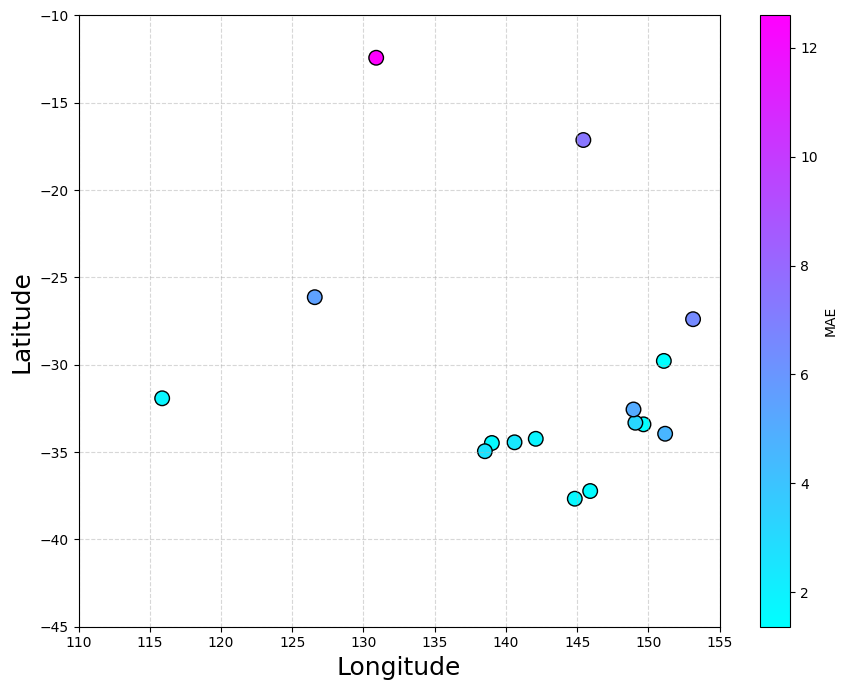

In [497]:
# Extract coordinates and MAE values
lons = [meta.loc[s, "lon"] for s in cv_tbl["holdout_station"]]
lats = [meta.loc[s, "lat"] for s in cv_tbl["holdout_station"]]
mae_vals = cv_tbl["MAE_IDW_climatology"]

fig, ax = plt.subplots(figsize=(9,7))

# Scatter plot
sc = ax.scatter(
    lons, lats,
    c=mae_vals,
    s=110,
    cmap="cool",   # or change if you prefer
    edgecolor="black"
)

# Add colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("MAE")

# Set geographic bounds (same as your Plotly map)
ax.set_xlim(110, 155)
ax.set_ylim(-45, -10)

# Labels and title
ax.set_xlabel("Longitude", fontsize=18)
ax.set_ylabel("Latitude", fontsize=18)

ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "mae_loc_lm_l.png")
plt.savefig(downloads_path, dpi=300)

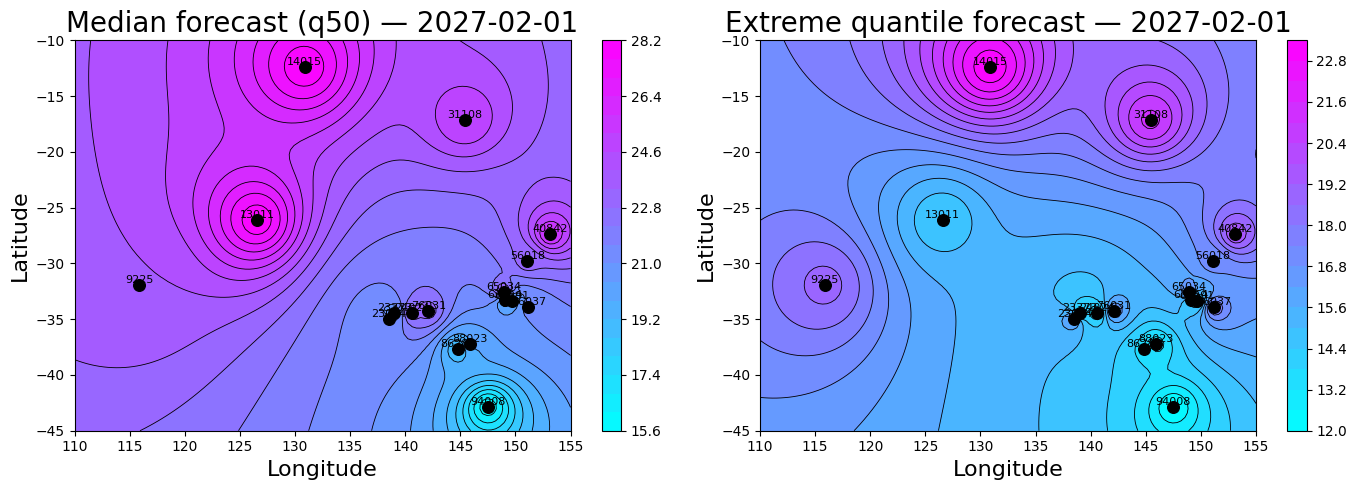

In [498]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# -----------------------------
# LEFT PANEL: Median forecast
# -----------------------------
cf1 = axs[0].contourf(
    lon_grid,
    lat_grid,
    Z_med,
    levels=20,
    cmap="cool"   # Cool colormap
)

# Contour lines (no numbers)
cl1 = axs[0].contour(
    lon_grid,
    lat_grid,
    Z_med,
    levels=20,
    colors="black",
    linewidths=0.6
)

# Plot station markers
axs[0].scatter(
    map_df["lon"],
    map_df["lat"],
    color='black',
    edgecolor="black",
    s=70
)

# Station labels
for i, station in enumerate(map_df["station"]):
    axs[0].text(
        map_df["lon"].iloc[i],
        map_df["lat"].iloc[i],
        str(station),
        fontsize=8,
        ha="center",
        va="bottom"
    )

axs[0].set_title(f"Median forecast (q50) — {MAP_DS.date()}", fontsize=20)
axs[0].set_xlabel("Longitude", fontsize=16)
axs[0].set_ylabel("Latitude", fontsize=16)

# Colorbar
fig.colorbar(cf1, ax=axs[0])

# -----------------------------
# RIGHT PANEL: Extreme quantile forecast
# -----------------------------
cf2 = axs[1].contourf(
    lon_grid,
    lat_grid,
    Z_ext,
    levels=20,
    cmap="cool"
)

cl2 = axs[1].contour(
    lon_grid,
    lat_grid,
    Z_ext,
    levels=20,
    colors="black",
    linewidths=0.6
)

axs[1].scatter(
    map_df["lon"],
    map_df["lat"],
    color='black',
    edgecolor="black",
    s=70
)

# Station labels
for i, station in enumerate(map_df["station"]):
    axs[1].text(
        map_df["lon"].iloc[i],
        map_df["lat"].iloc[i],
        str(station),
        fontsize=8,
        ha="center",
        va="bottom"
    )

axs[1].set_title(f"Extreme quantile forecast — {MAP_DS.date()}", fontsize=20)
axs[1].set_xlabel("Longitude", fontsize=16)
axs[1].set_ylabel("Latitude", fontsize=16)

fig.colorbar(cf2, ax=axs[1])

# -----------------------------
# Final layout
# -----------------------------
plt.tight_layout()
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "idw_lm_l.png")
plt.savefig(downloads_path, dpi=300)
plt.show()

In [ ]:
# ==========================
# Forecast tables + station-specific plots
# ==========================

# Create a forecast table for all stations and all future months
forecast_tbl = future[["station","ds","lat","lon","q25","q50","q75","bulk_ext_q","evt_ext_q"]].copy()
for col in ["q25","q50","q75","bulk_ext_q","evt_ext_q"]:
    forecast_tbl["y_"+col] = from_working_scale(forecast_tbl[col], TARGET)

save_table(forecast_tbl, f"forecast_table_{TARGET}_{TAIL}")
display(forecast_tbl.head())

# Plot forecast for a chosen station
def plot_station_forecast(station_id):
    g = forecast_tbl.loc[forecast_tbl["station"]==station_id].sort_values("ds").copy()
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=g["ds"], y=g["y_q50"], mode="lines+markers", name="Forecast median (q50)"))
    # IQR band
    fig.add_trace(go.Scatter(x=g["ds"], y=g["y_q75"], mode="lines", name="q75", opacity=0.6))
    fig.add_trace(go.Scatter(x=g["ds"], y=g["y_q25"], mode="lines", name="q25", opacity=0.6, fill="tonexty"))
    # EVT extreme
    fig.add_trace(go.Scatter(x=g["ds"], y=g["y_evt_ext_q"], mode="lines", name=f"EVT extreme q{int(100*EXT_Q_X)}", line=dict(dash="dash")))
    fig.update_layout(title=f"Forecast for station {station_id} — TARGET={TARGET}",
                      xaxis_title="date", yaxis_title="value (original units)")
    save_fig(fig, f"forecast_station_{station_id}_{TARGET}_{TAIL}")

# Always plot the example station
plot_station_forecast(EXAMPLE_STATION)

# Optionally plot all stations (uncomment if you want 17 plots)
# for st in sorted(forecast_tbl["station"].unique()):
#     plot_station_forecast(st)


In [ ]:
def plot_station_forecast(station_id):
    # Select station data
    g = forecast_tbl.loc[forecast_tbl["station"]==station_id].sort_values("ds").copy()
    
    fig, ax = plt.subplots(figsize=(12,6))
    
    # Colors
    colors = {
        "median": "cyan",
        "IQR": "plum",
        "EVT_extreme": "mediumpurple"
    }
    
    # Forecast median (q50)
    ax.plot(g["ds"], g["y_q50"], marker='o', markersize=6, color=colors["median"],
            label="Forecast median (q50)", linewidth=2)
    
    # IQR band
    ax.fill_between(g["ds"], g["y_q25"], g["y_q75"], color=colors["IQR"], alpha=0.4, label="IQR (q25–q75)")
    
    # EVT extreme quantile
    ax.plot(g["ds"], g["y_evt_ext_q"], color=colors["EVT_extreme"], linestyle='--',
            label=f"EVT extreme q{int(100*EXT_Q_X)}", linewidth=2)
    
    # Labels and title
    ax.set_xlabel("Date")
    ax.set_ylabel("Value (original units)")
    ax.set_title(f"Forecast for Station {station_id} - Precipitation")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
plot_station_forecast(EXAMPLE_STATION)
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "forecast_precip.png")
plt.savefig(downloads_path, dpi=300)


In [ ]:
# ==========================
# Build index.html and (optional) zip outputs
# ==========================

index_path = build_index_html()
print("Wrote:", index_path)

# Optional: create a zip of OUTPUT_DIR (handy for submission/sharing)
import zipfile

zip_path = OUTPUT_DIR.rstrip("/").rstrip("\\") + ".zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for f in files:
            full = os.path.join(root, f)
            rel  = os.path.relpath(full, OUTPUT_DIR)
            zf.write(full, arcname=rel)

print("Wrote:", zip_path)


## Optional extensions (advanced models)

Everything above is **dependency-light** (NumPy + Pandas + Plotly) and should run in a standard environment.

If you want to strengthen the modelling section in the report, here are natural “next” models:

### 1) Statsmodels SARIMA/SARIMAX (classic seasonal ARIMA)
- Pros: interpretable, strong baseline for seasonal series.
- Cons: adds a compiled dependency stack (may be fragile under NumPy 2 on some machines).

### 2) Multivariate VAR (sun + temperatures)
- Pros: captures cross-variable dependence (sun ↔ temperature).
- Cons: needs careful stationarity preprocessing.

### 3) Darts (ML/DL forecasting)
- Pros: lots of models in one API, can handle covariates, probabilistic forecasts.
- Cons: larger dependency footprint, more tuning.

Below we give short, **clearly labelled** code blocks. They are NOT required for the main pipeline.



In [ ]:
# ==========================
# OPTIONAL: advanced model playground
# ==========================

RUN_ADVANCED = True  # set True if you want to run these extra sections

if RUN_ADVANCED:
    print("Running advanced models...")

    # ------------------------------------------------------------
    # (A) statsmodels SARIMA/SARIMAX (if available)
    # ------------------------------------------------------------
    try:
        import statsmodels.api as sm
        from statsmodels.tsa.statespace.sarimax import SARIMAX

        # Example: fit SARIMA on the pooled median series (working scale if rain)
        pooled_work = pooled[["ds", TARGET]].copy()
        pooled_work["x"] = to_working_scale(pooled_work[TARGET], TARGET)
        pooled_work = pooled_work.dropna(subset=["x"]).set_index("ds")["x"]

        # A simple seasonal specification to start (you will tune this!)
        # For monthly seasonal series, seasonal_periods = 12
        model = SARIMAX(pooled_work, order=(1,0,1), seasonal_order=(1,1,1,12), trend="c")
        res = model.fit(disp=False)
        print(res.summary())

        # Forecast
        fc = res.get_forecast(steps=HORIZON)
        mean_fc = fc.predicted_mean
        ci = fc.conf_int()

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=pooled_work.index, y=from_working_scale(pooled_work.values, TARGET), mode="lines", name="history"))
        fig.add_trace(go.Scatter(x=mean_fc.index, y=from_working_scale(mean_fc.values, TARGET), mode="lines+markers", name="SARIMA mean forecast"))
        fig.update_layout(title=f"SARIMA example on pooled series — TARGET={TARGET}")
        save_fig(fig, f"advanced_sarima_pooled_{TARGET}")

    except Exception as e:
        print("[advanced] statsmodels SARIMAX not available or failed:", e)

    # ------------------------------------------------------------
    # (B) Simple VAR (implemented with NumPy, dependency-light)
    # ------------------------------------------------------------
    # Example: VAR on pooled (sun, highest_min, lowest_max) after seasonal differencing
    Y = pooled.set_index("ds")[["sun","highest_min","lowest_max"]].dropna().copy()
    Y_sd = Y.diff(12).dropna()

    def fit_var(Y, p=2):
        """Fit VAR(p): Y_t = c + A1 Y_{t-1} + ... + Ap Y_{t-p} + e_t."""
        Y = np.asarray(Y, float)
        T, k = Y.shape
        # build design matrix
        X = []
        Yt = []
        for t in range(p, T):
            row = [1.0]
            for j in range(1, p+1):
                row.extend(Y[t-j])
            X.append(row)
            Yt.append(Y[t])
        X = np.asarray(X, float)         # (T-p) × (1 + k*p)
        Yt = np.asarray(Yt, float)       # (T-p) × k
        B = np.linalg.lstsq(X, Yt, rcond=None)[0]  # (1+k*p) × k
        return B

    def forecast_var(Y_hist, B, h=12, p=2):
        """Forecast h steps ahead from history using fitted VAR coefficients."""
        Y_hist = [np.asarray(v, float) for v in Y_hist]
        k = Y_hist[0].shape[0]
        out = []
        for step in range(h):
            row = [1.0]
            for j in range(1, p+1):
                row.extend(Y_hist[-j])
            row = np.asarray(row, float)
            y_next = row @ B
            out.append(y_next)
            Y_hist.append(y_next)
        return np.asarray(out)

    p = 2
    B = fit_var(Y_sd.values, p=p)
    fc_sd = forecast_var(list(Y_sd.values[-p:]), B, h=HORIZON, p=p)

    # Convert seasonal differences back to levels is nontrivial for multivariate;
    # the simplest plot is to show the differenced forecasts themselves.
    fig = go.Figure()
    for i, col in enumerate(Y_sd.columns):
        fig.add_trace(go.Scatter(x=Y_sd.index, y=Y_sd[col], mode="lines", name=f"sd({col}) history"))
        fig.add_trace(go.Scatter(x=future_ds, y=fc_sd[:,i], mode="lines+markers", name=f"sd({col}) VAR forecast"))
    fig.update_layout(title="VAR(p) on seasonally differenced pooled series (demo)")
    save_fig(fig, "advanced_var_demo")

    # ------------------------------------------------------------
    # (C) Darts (if you want ML/DL models)
    # ------------------------------------------------------------
    # Install (in a terminal): pip install u8darts[torch] or u8darts[all]
    # Then see: https://github.com/unit8co/darts
